Preprocessing: Checking data objects 

In [32]:
import scanpy as sc
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import celltypist
import seaborn as sns
import numpy as np
import harmonypy as hm

In [33]:
# Data retrieval
sc.settings.set_figure_params(dpi=50, facecolor="white")

# Load your liver FACS Smart-seq2 data
adata = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-Liver.h5ad")  # path to your file

# Make sure variable (gene) names are unique
adata.var_names_make_unique()

# Make sure observation (cell) names are unique
adata.obs_names_make_unique()

# Inspect AnnData object
print(adata)

#display the pandas crosstab 
print(pd.crosstab(adata.obs['age'], adata.obs['mouse.id']))

AnnData object with n_obs × n_vars = 2859 × 22966
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden'
    var: 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'age_colors', 'cell_ontology_class_colors', 'leiden', 'louvain', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
mouse.id  3_9_M  3_11_M  3_56_F  3_57_F  18_45_M  18_46_F  18_53_M  24_58_M  \
age                                                                           
3m          150     420      82      79        0        0        0        0   
18m           0       0       0       0      275      533      372        0   
24m           0       0       0       0        0        0        0      508   

mouse.id  24_59_M  
age                
3m              0  
18m             0  
24m   

In this data we have 2859 cells total and 22966 genes. These cells come from mice that have different ages and sexes, specifically: 4 mice (2 male and two female) with 3 months, 3 mice (2 male and 1 female) with 18 months and 2 (2 male) mice with 24 months.

Here the batch effect must be studied carefully because there are many variables that could be interpreted as such when actually they are biological differences derived from any one of these variables (age and sex), assuming that the mice with the same age and sex are replicates.

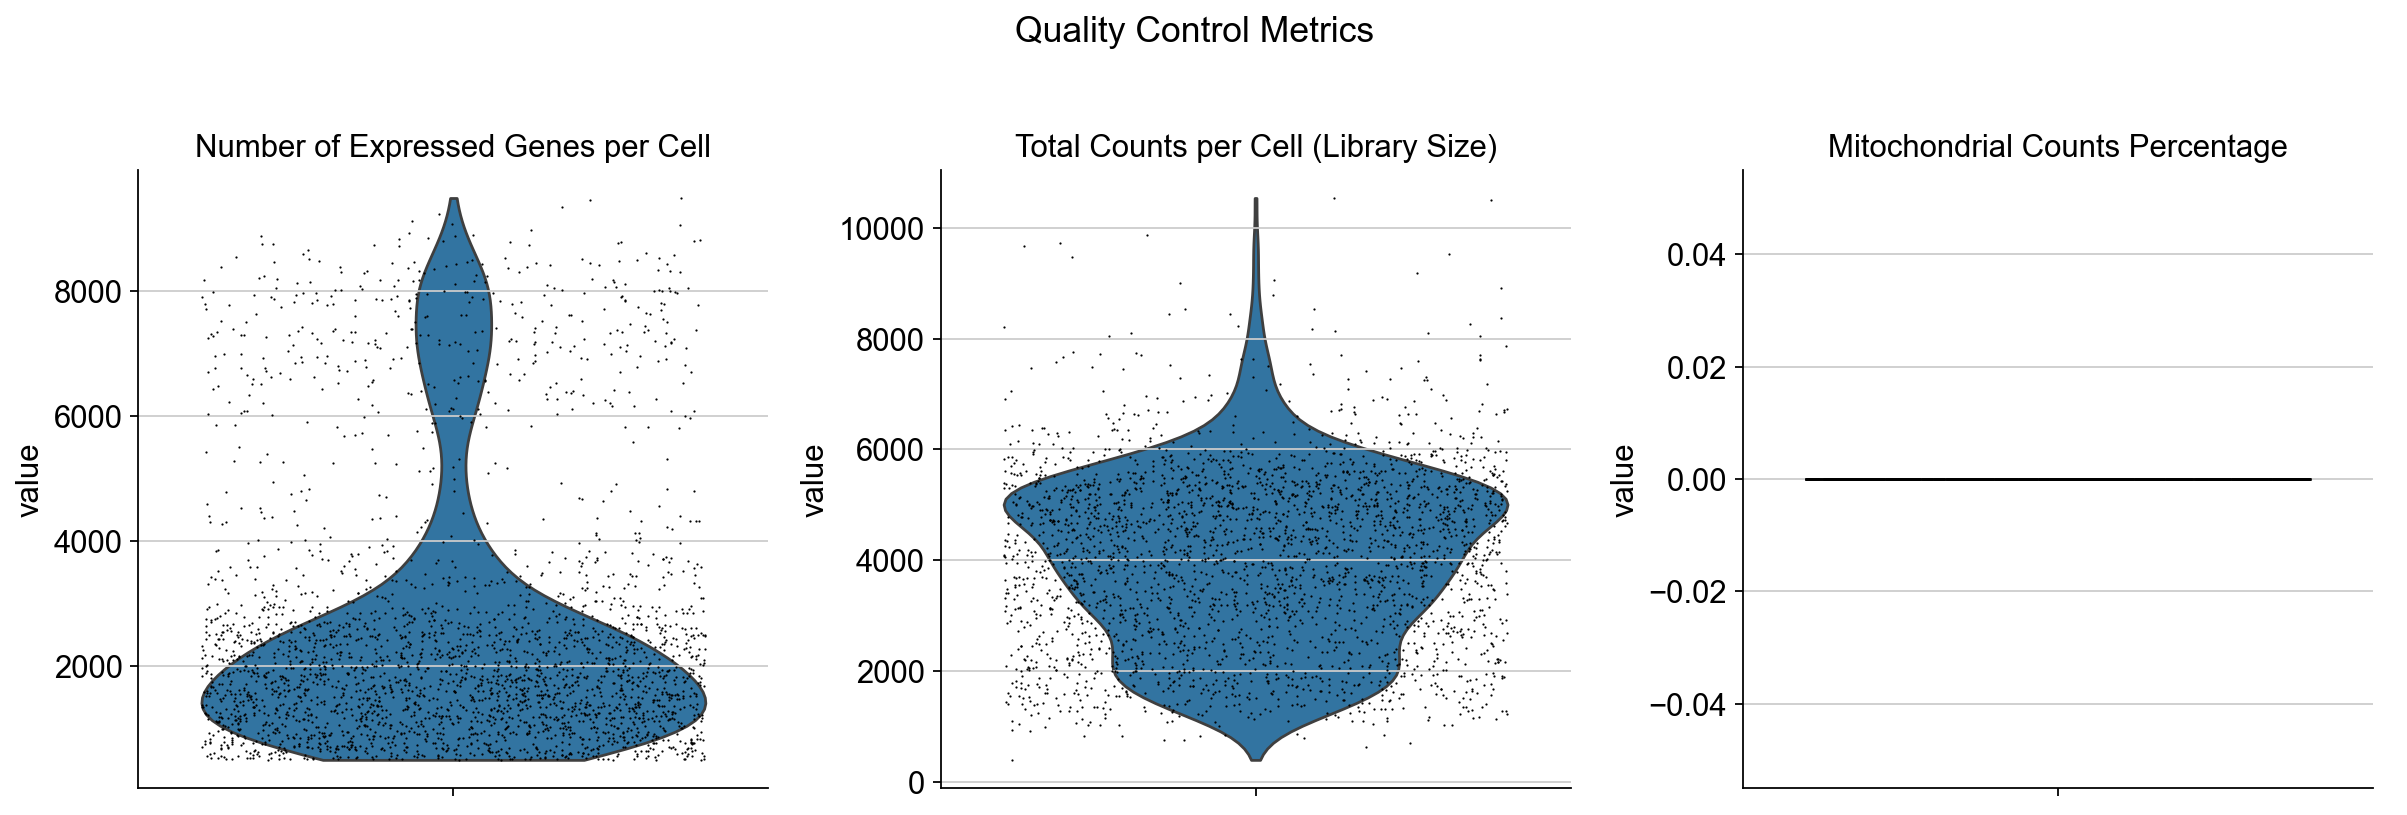

In [34]:
sc.settings.set_figure_params(dpi=80, facecolor="white")

# --- Step 1: Identify mitochondrial genes ---
adata.var['mt'] = adata.var_names.str.startswith('mt-')

# --- Step 2: Calculate QC metrics, including mitochondrial percentage ---
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# --- Step 3: Visualize all key QC metrics ---
# Add 'pct_counts_mt' to the list of variables to plot
grid = sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    show=False  # IMPORTANT: Do not show the plot immediately
)

# Flatten the 2D array of axes into a 1D list and set titles
flat_axes = grid.axes.flatten()
flat_axes[0].set_title('Number of Expressed Genes per Cell')
flat_axes[1].set_title('Total Counts per Cell (Library Size)')
flat_axes[2].set_title('Mitochondrial Counts Percentage')

# Add an overall title to the entire figure
grid.fig.suptitle('Quality Control Metrics', fontsize=16, y=1.02) # y adjusts vertical position

# Adjust layout to prevent titles from overlapping and then show the plot
plt.tight_layout()
plt.show()

QC

Specific gene IDs like Mt and HB can't be used because my data uses Ensembl style IDs, meaning that these prefixes don't match any gene and the counts that they would produce would be zero.

And since the data doesnt provide the gene IDs for mapping, the only option would be to use a lookup table. Since I am more interested in the clustering per cell type, I will skip specific gene counts.

These are the violin plots for the full data.

On the left we have the Number of unique gene counts per cell. 

Shows how many unique genes were detected with a least one count per cell. The y-axis shows the number of genes and the x-axis shows the individual cells. In this case we can see that the larger subset of cells appears to be around 2000 unique genes per cell, with another much smaller subset of cells with 8000 unique genes.

What this means: the larger subset is most likely high quality data, since this is the expected number for smartseq2 data or mitochondrial data, while the smaller subset may be doublets (two cells captured together) or very highly sequenced cells, which one explanation for such a large increase in unique genes in these cells.

On the right we have the Total gene counts per cell.

Shows the sum of total reads across all genes in a given cell. The y-axis shows the value of the gene count and the x-axis the cells. Here we have a large distribution of cells that have total gene counts increasing from around 2000 all the way to a peak of around 5000. We see a dropoff in total gene counts, with only a few outlier cells having higher total gene counts.

What this means: Again we see a main population of cells that have total gene counts of around 2000 to 5000 representing our main high quality population, which is in line with data from smartseq2. This gradual increase could be either doublets or, again, very well sequenced cells that, because they have higher depth, more genes were detected and individualized. Or it could have a biological reason, differing ages/sexes or cell types can express a different transcriptome.

To visualize both sex and age as potentials for a batch effect would be difficult in violin plots so lets do it in a scatter plot.

Also, when trying to visualize the mitochondrial genes, I noticed that my code didn't detect any. After careful investigation, this is most likely because the researchers already processed and filtered these mitochondrial genes. So the purpose of visualizing these genes is moot, since I also would've wanted to filter them out if the data required it.

Meaning that the smaller population of cells with higher than average unique genes is of note.

... storing 'age_sex' as categorical


Created new categories in 'age_sex':
['18m_female', '18m_male', '24m_male', '3m_male', '3m_female']




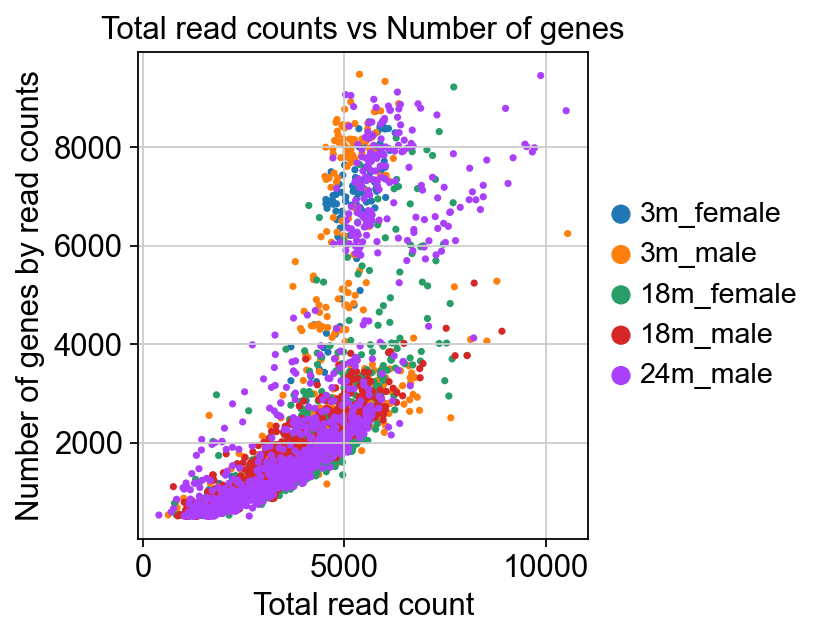

In [38]:
# --- Create a new metadata column by combining 'age' and 'sex' ---
adata.obs['age_sex'] = adata.obs['age'].astype(str) + '_' + adata.obs['sex'].astype(str)

print("Created new categories in 'age_sex':")
print(adata.obs['age_sex'].unique().tolist())
print("\n")

# --- Plot using the new combined column for color ---
ax = sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="age_sex",
    title="Total read counts vs Number of genes",
    show=False  # Set to False so we can modify the labels
)

# --- Add your custom labels here ---
ax.set_xlabel("Total read count")
ax.set_ylabel("Number of genes by read counts")

import matplotlib.pyplot as plt
plt.show()

Scatter plot graph shows the comparison between total gene counts per cell in the x-axis and number of unique gene counts per cell in the y-axis.

There is a higher concentration of cells across the comparison between the two axis around 2000 to 4000 number of unique genes and 0 to 5000 total gene counts. This is our main population of cells. Then we can see that there are more than a few "outliers", could even be a smaller population of cells, that have higher overall unique gene counts but not total gene counts. This could be technical errors or they could be biological differences since we can see that not all groups are represented in this smaller population, like the 18 month male mouse.

What this means: This graph corroborates the information given by the violin plots, with the identification of the subset that could be doublets or biological heterogeneity. The subtle difference in the categories could be sufficient for a batch correction, if it is caused by technical factors, but the information so far is insufficient to say.

Doublet Detection

The tutorial says: "We can remove doublets by either filtering out the cells called as doublets, or waiting until we’ve done a clustering pass and filtering out any clusters with high doublet scores."

My batch effects were minor, if at all present, but it is still recommended to do a doublet detection and possible removal before a possible batch correction. Since leaving them until after a first clustering pass may create clusters where doublets dominate. 

In [ ]:
sc.settings.set_figure_params(dpi=50, facecolor="white")

# Run Scrublet doublet detection, per sample/batch
sc.pp.scrublet(adata)  # or "sample" if you prefer

# Quick look at the added columns
print(adata.obs[['doublet_score', 'predicted_doublet']].head())

# Check the total number of cells before filtering
original_counts = adata.n_obs
print("Original counts before removing doublets:")
print(original_counts)

# Check number of predicted doublets
doublet_counts = adata.obs['predicted_doublet'].sum()
print("\nNumber of predicted doublets:")
print(doublet_counts)

#Remove predicted doublets
adata = adata[~adata.obs['predicted_doublet'], :].copy()

#Save filtered data
adata.write("Liver_facs_filtered.h5ad")

Running Scrublet
filtered out 5868 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


KeyboardInterrupt: 

This output is in line with the interpretations of the distributions of the violin and scatter plots that saw a minor amount of cells belonging to the outlier groups of cells. Since this is a single cell, even if I am using a tool and code recommended by the ScanPy tutorial, I will remove it from the dataset because it won't affect the downstream analysis.

Verifying that your total gene matrix includes at least one count per gene is a fundamental and crucial quality control step in RNA sequencing analysis. Genes with zero counts across all your samples (cells) are uninformative and can negatively impact downstream analyses.

- Reduces Noise and Unnecessary Data
- Improves Statistical Power: In downstream analyses like differential gene expression, you perform a statistical test for every gene. 
- Normalization: Methods like Counts Per Million (CPM) or scaling factor calculations can be affected by the inclusion of a large number of zero-count genes.
- Log-transformation: Taking the logarithm of zero is undefined. While a "pseudocount" (adding a small value, like 1, to all counts) is a common workaround, it's best practice to first remove genes that are all zeros as they provide no useful variance

In [ ]:
filename = 'Liver_facs_filtered.h5ad'
output_filename = 'Liver_facs_filtered_nonzero.h5ad'

print(f"Loading data from: {filename}")
adata = sc.read_h5ad(filename)
print(f"Original object shape (cells × genes): {adata.shape}")

# ... (Verification steps 1-4 are the same) ...
raw_counts_matrix = adata.X
gene_counts_sum = np.array(raw_counts_matrix.sum(axis=0)).flatten()
genes_to_keep_mask = gene_counts_sum > 0
num_genes_to_remove = adata.n_vars - genes_to_keep_mask.sum()

# 5. Filter the data if necessary.
if num_genes_to_remove > 0:
    print(f"Found {num_genes_to_remove} genes with zero counts. Filtering them out.")
    adata_filtered = adata[:, genes_to_keep_mask].copy()
    print(f"New filtered object shape: {adata_filtered.shape}")

    # --- CORRECTED SAVE ---
    print(f"Saving filtered data to: {output_filename}")
    adata_filtered.write(output_filename)

else:
    print("\n✅ All genes have at least one count. No filtering was necessary.")

    # --- CORRECTED SAVE (for the 'else' case) ---
    print(f"Saving original (unfiltered) data to: {output_filename}")
    adata.write(output_filename)

Loading data from: Liver_facs_filtered.h5ad
Original object shape (cells × genes): (2858, 22966)
Found 3407 genes with zero counts. Filtering them out.
New filtered object shape: (2858, 19559)
Saving filtered data to: Liver_facs_filtered_nonzero.h5ad


Here I filtered my data based on every gene having at least one read that mapped to it, discarding genes with 0 reads thereby increasing their signal and improving the downstream normalization as mentioned above.

Normalization

Here I normalized the data based on the metric suggested by the ScanPy tutorial of median count depth with log1p transformation.

In [ ]:
# Load the filtered of doublets data
adata = sc.read_h5ad("Liver_facs_filtered_nonzero.h5ad")
adata.var_names_make_unique()
adata.obs_names_make_unique()

# Save the raw counts in a separate layer
adata.layers["counts"] = adata.X.copy()

# Normalize each cell by total counts to median count depth
sc.pp.normalize_total(adata)  # default: target_sum = median count depth

# Log1p transform (log(x + 1))
sc.pp.log1p(adata)

# Quick check
print(adata)

# After normalization and log1p
adata.write("Liver_facs_filtered_nonzero_normalized.h5ad")

AnnData object with n_obs × n_vars = 2858 × 19559
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'age_sex', 'doublet_score', 'predicted_doublet'
    var: 'n_cells', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'age_colors', 'age_sex_colors', 'cell_ontology_class_colors', 'leiden', 'louvain', 'neighbors', 'pca', 'scrublet', 'log1p'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connec

The normalized (based on the median count depth) and log1p transformed data are now saved as objects in the file, and are accessable for downstream analysis.

Median count depth: Count depth is the total number of reads (or UMIs) captured for a single cell. In the dataset of 2,858 cells, the count depth will vary wildly. A gene with a raw count of 50 in the "deep" cell and 5 in the "shallow" cell might actually be expressed at the exact same biological level. The difference in raw counts is a technical artifact, not a biological reality. We also use the median instead of the mean because its statistically robust to outliers.

Feature Selection

Here I want to reduce the dimensionality of the dataset and only include the most informative genes. To identify genes that exhibit high cell-to-cell variability, as these are more likely to be biologically significant and useful for distinguishing different cell types and states.

The result of the output will be the selection of 2000, as instructed by the tutorial, highly variable genes (HGV), and the remaining difference of non HGVs.

highly_variable
False    17553
True      2006
Name: count, dtype: int64


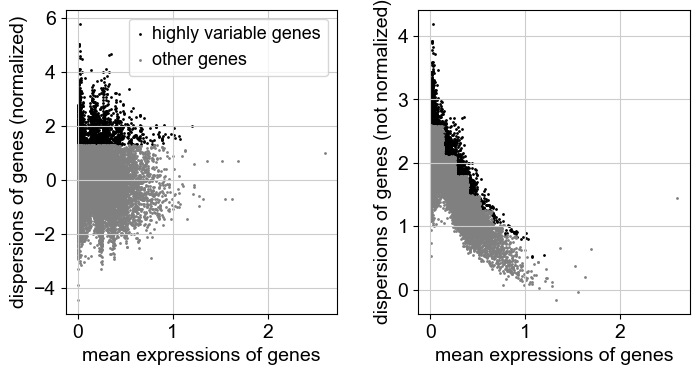

In [ ]:
# Load the filtered, normalized data
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized.h5ad")
adata.var_names_make_unique()
adata.obs_names_make_unique()

# Highly variable gene selection
# n_top_genes = 2000 as in the tutorial
# batch_key = "batch" to account for multiple batches
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Quick check of HVG annotation
print(adata.var.highly_variable.value_counts())

# Plot the highly variable genes
sc.pl.highly_variable_genes(adata)

# Save the HVG-annotated data for the next step
adata.write("Liver_facs_filtered_nonzero_normalized_HVG.h5ad")

The left plot (NORMALIZED). Here it hows in the x-axis the average expression level of each gene across all cells and in the y-axis the variability of each gene's expression. Dispersion is a measure of how much the gene's expression varies from its mean value. where the dispersion values have been standardized. This normalization process typically involves fitting a model to the mean-dispersion trend observed, on the right, and then calculating a z-score or a residual (difference between the actual point and the model fitted point) for each gene.

The right plot (NOT NORMALIZED). Typically, genes with higher mean expression tend to have lower dispersion (less variability relative to their mean), which is the trend followed by the grey points ("other genes"). The genes identified as "highly variable genes" (HVGs), marked in black, are those that deviate significantly from this expected trend. They show a higher dispersion than other genes with a similar mean expression level. This indicates that their variability is not just a consequence of their expression level but is likely driven by underlying biological processes.

What this means: The "highly variable genes" (black dots) are now clearly identifiable as the points with high positive normalized dispersion scores. This plot confirms that the selection has successfully captured genes with variability that is statistically significant above the technical noise and the expected biological variance.

Also, the choice of the amount of HVGs comes from the authors of the Seurat (a commonly used Bioinformatic analytical package sued in R) package, who found it to be a robust default that works well across a wide variety of datasets. 

Reasons to Keep 2,000 (or even increase it to 3,000):
- High Cellular Complexity
- Subtle Biological Signal
- Exploratory Analysis

Reasons You Might Decrease the Number (e.g., to 1,500):
- Extremely Noisy Data (e.g., high mitochondrial content, low gene counts per cell)
- Over-clustering of a Homogeneous Population
- Very Simple Datasets

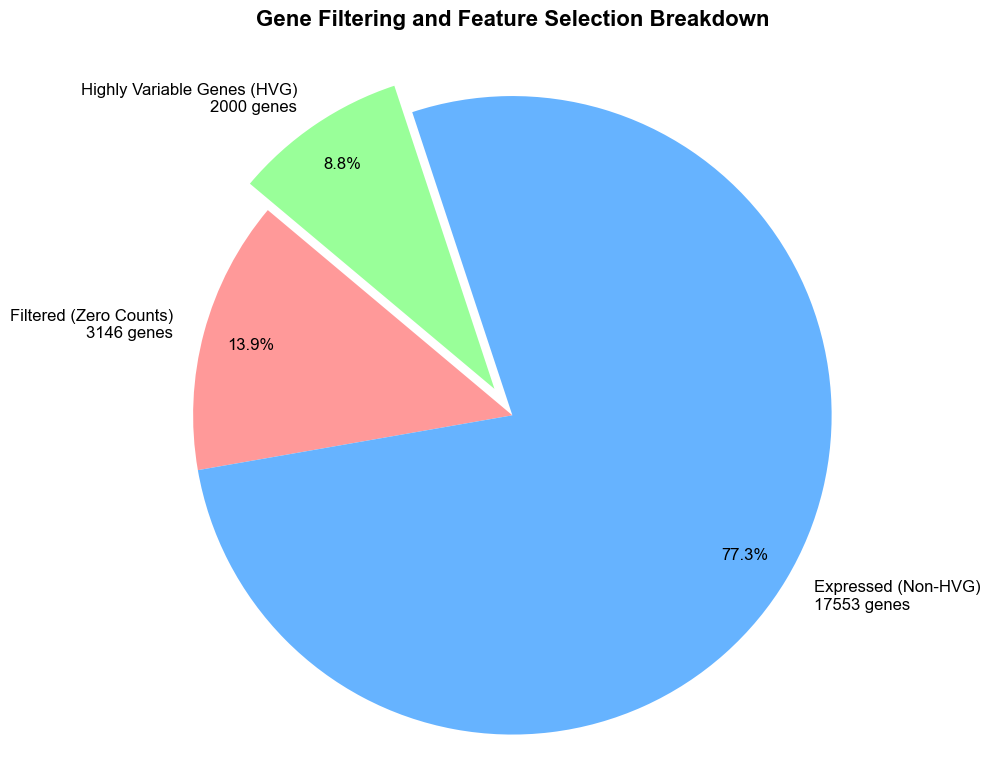

In [ ]:
import matplotlib.pyplot as plt

# --- 1. Data from your analysis ---
# TODO: Replace these numbers with the exact values from your dataset.
original_total_genes = 22699
genes_after_filtering = 19553
hvg_genes = 2000

# --- 2. Calculate the size of each slice ---
# The pie chart represents the fate of the *original* total genes.
# Slice 1: Genes that were filtered out (had zero counts)
filtered_genes = original_total_genes - genes_after_filtering

# Slice 2: Genes that were kept after filtering but were NOT selected as HVGs
expressed_non_hvg_genes = genes_after_filtering - hvg_genes

# Slice 3: The Highly Variable Genes that were used for analysis
# This is simply `hvg_genes`

# --- 3. Prepare data for the pie chart ---
sizes = [filtered_genes, expressed_non_hvg_genes, hvg_genes]
labels = [
    f'Filtered (Zero Counts)\n{filtered_genes} genes',
    f'Expressed (Non-HVG)\n{expressed_non_hvg_genes} genes',
    f'Highly Variable Genes (HVG)\n{hvg_genes} genes'
]
colors = ['#ff9999', '#66b3ff', '#99ff99'] # A nice color scheme: red, blue, green
explode = (0, 0, 0.1)  # "Explode" the HVG slice to emphasize it

# --- 4. Create and display the pie chart ---
plt.figure(figsize=(10, 8)) # Set a good figure size

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',  # Add percentages to the slices
    startangle=140,      # Rotate the start of the pie for better label placement
    explode=explode,
    pctdistance=0.85,    # Move percentage labels inside the slices
    textprops={'fontsize': 12} # Set font size for labels
)

# Add a title to the chart
plt.title('Gene Filtering and Feature Selection Breakdown', fontsize=16, fontweight='bold', pad=20)

# Ensure the pie is drawn as a circle
plt.axis('equal')

# Improve layout to prevent labels from being cut off
plt.tight_layout()

# Show the plot
plt.show()

This is a pie chart to visualize the gene filtering and subsetting done in the original dataset of 22966 genes.

From the AI: UMI‑based droplet platforms (10x, Drop‑seq) typically show the highest sparsity, frequently in the 70–90% zero range, because each cell has relatively few captured transcripts. While full‑length methods (e.g. Smart‑seq2) usually show fewer zeros per cell, because they achieve higher per‑cell coverage and detect more genes, though sparsity is still far higher than in bulk.

Dimensionality Reduction

Here we aim to reduce the dimensionality of the data, meaning the amount of genes, by running principal component analysis (PCA), which reveals the main axes of variation and denoises the data. I will use only the highly variable genes (HVGs) for PCA.

computing PCA
    with n_comps=50
    finished (0:00:01)


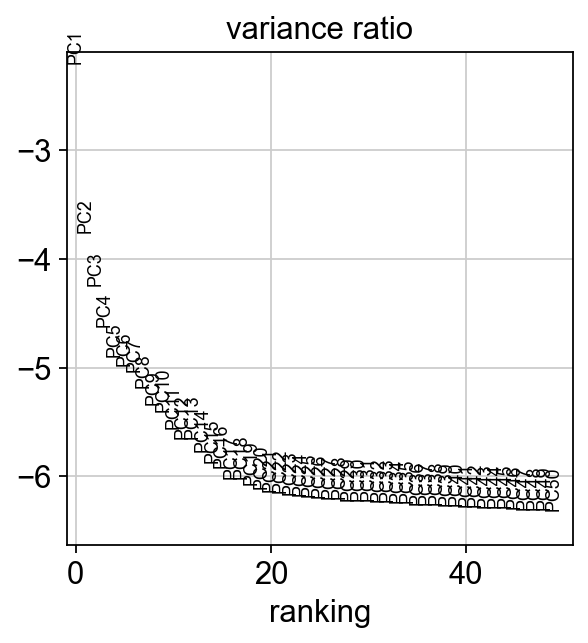

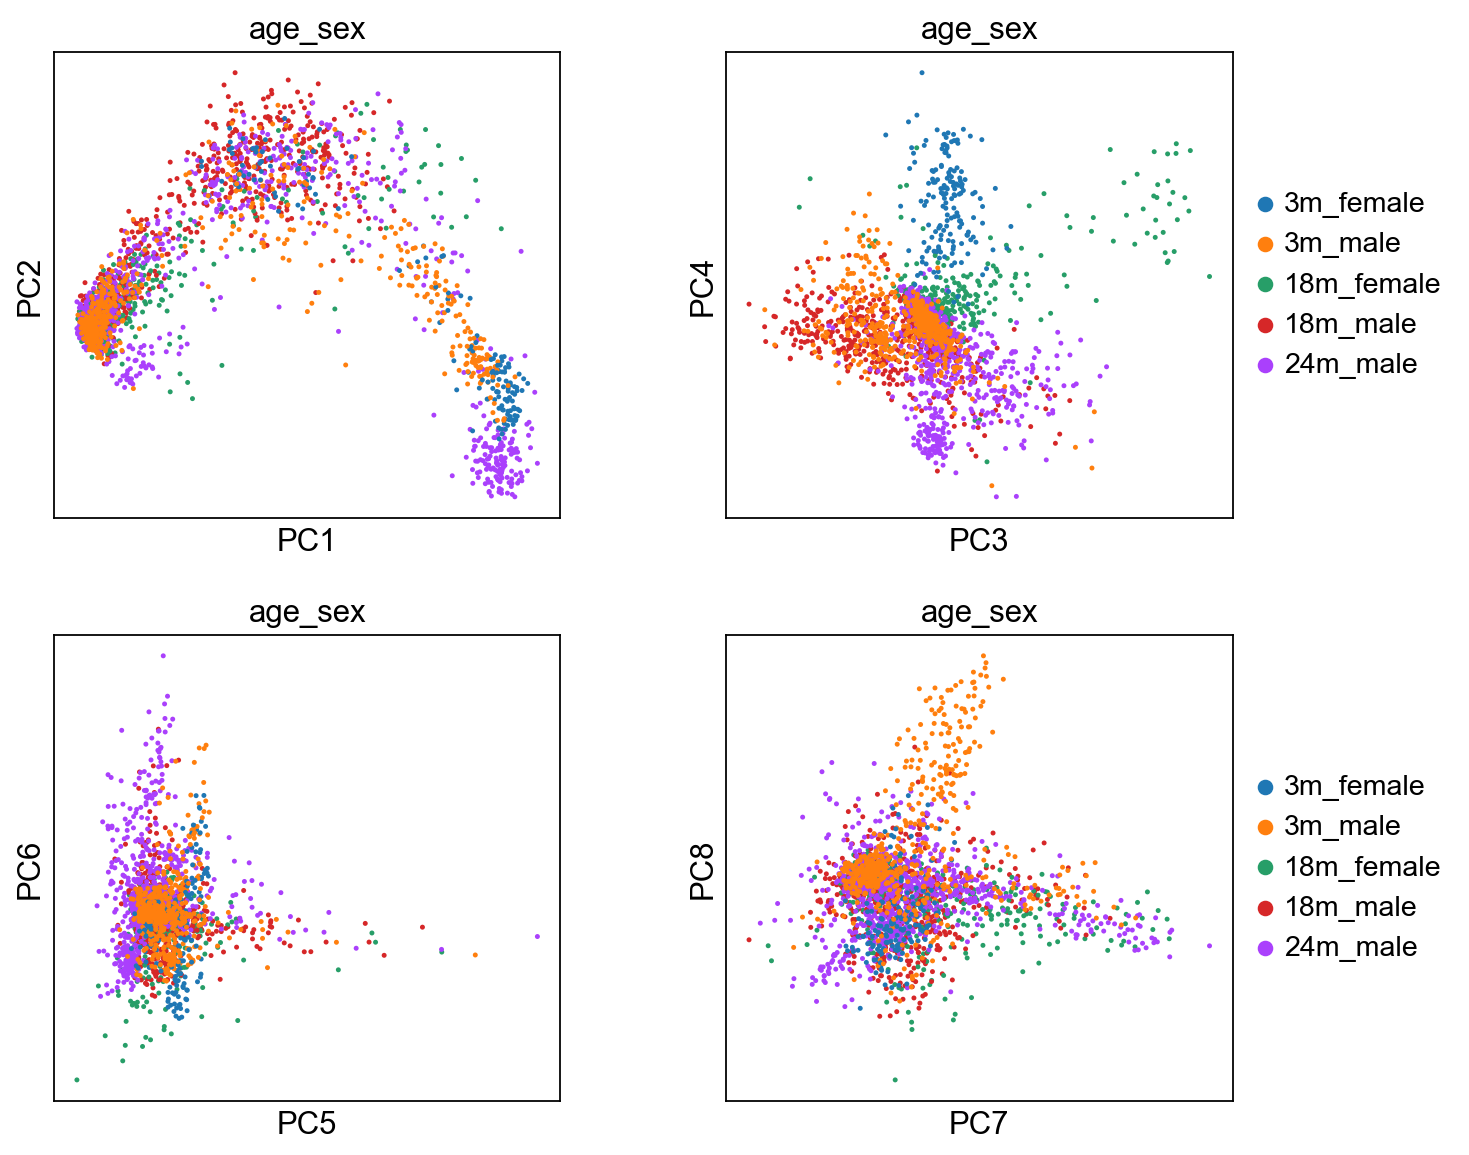

PCA done. Dataset shape: (2858, 19559)


In [39]:
import scanpy as sc
import matplotlib.pyplot as plt

# Load and scale data
adata = sc.read_h5ad("Liver_facs_filtered_nonzero_normalized_HVG.h5ad")
adata.var_names_make_unique()
adata.obs_names_make_unique()
sc.pp.scale(adata, max_value=10)

# Run PCA
sc.tl.pca(adata, n_comps=50, svd_solver='arpack')

# Inspect variance
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, show=True)

# --- PCA scatter plots with legend control ---
# Capture the axes by setting show=False
axes = sc.pl.pca(
    adata,
    color=["age_sex"],
    dimensions=[(0, 1), (2, 3), (4, 5), (6, 7)],
    ncols=2,
    size=20,
    show=False
)

# Since ncols=2:
# index 0 = Col 1, index 1 = Col 2
# index 2 = Col 1, index 3 = Col 2
for i, ax in enumerate(axes):
    # If the index is even (0, 2...), it's the first column
    if i % 2 == 0:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

# Adjust layout and show
plt.tight_layout()
plt.show()

# Save the PCA-processed dataset
adata.write("Liver_facs_filtered_nonzero_normalized_HVG_reduced.h5ad")
print("PCA done. Dataset shape:", adata.shape)


The first plot gives us how much variance (relative importance) of each principal component (Scree Plot). Basically how much information each principal component captures, giving us a better perspective on how much information we can use in downstream analysis.

You want to keep enough PCs to capture the true biological signal in your data, but discard the later PCs which are more likely to represent technical noise. This plot helps you find the point of diminishing returns.

The plot shows a very gradual indicator of diminishing return of variance explained by later PCs. With an elbow possibly appearing around PC17 to PC20. This could be a good starting point to investigate as a means to keep biological heterogeneity. Of course, some technical noise may very likely be present but given that some of the cell types, like immune cells, are harder to distinguish a better granularity downstream is better.

The second plot shows us how the data was distributed and is compared between the principal components. Here we can see a good overall mix of the data in all 4 plots, indicating less batch effect that could be expected in a larger dataset. But we also see certain trends, especially because we have colored the plots by age_sex (our new column helping us identify individual differences). For example, comparing PC3 and PC4 there are different populations of cells trending in different directions, like 3 month female and 18 month female. This could indicate a biological signal that changes with age and not sex.

Batch Correction

Since the data is very heterogenous and there is more than one biological variable the segregation by batches is harder to define and so it is harder to identify batch effects and justify their correction.

The goal of batch correction here is to mix the male and female cells together so that the remaining variation in the data is driven by other factors (like age or cell type), not by sex.

But i will give examples of how we could do a batch correction:

In [ ]:
# --- Setup ---
input_filename = 'Liver_facs_filtered_nonzero_normalized.h5ad'
output_filename = 'Liver_facs_filtered_nonzero_normalized_corrected.h5ad'

# --- Main Regression Script ---

print(f"Loading data from: {input_filename}")
try:
    adata = sc.read_h5ad(input_filename)
except FileNotFoundError:
    print(f"Error: The file '{input_filename}' was not found. Please ensure it is in the correct directory.")
    exit()

print(f"\nData shape: {adata.shape}")
print("Assuming the data in adata.X is already normalized and log-transformed.")

# --- 1. Prepare Covariates for Regression ---
key_to_regress = 'sex'
print(f"\nPreparing '{key_to_regress}' variable for regression...")

if adata.obs[key_to_regress].isnull().any():
    print(f"Warning: Found missing values in the '{key_to_regress}' column.")
    adata = adata[~adata.obs[key_to_regress].isnull(), :].copy()
    print(f"Removed cells with missing values. New shape: {adata.shape}")
else:
    print(f"No missing values found in '{key_to_regress}'.")

# --- 2. Perform the Regression ---
print(f"Performing regression to remove effects of '{key_to_regress}'...")

# --- THIS IS THE FIX ---
# By setting n_jobs=None (or n_jobs=1), we force the function to run
# on a single core, avoiding the parallelization bug.
sc.pp.regress_out(
    adata,
    keys=[key_to_regress],
    n_jobs=None  # Explicitly disable parallelization
)
print("Regression complete.")


# --- 3. Save the Result ---
#print(f"\nSaving regression-corrected data to: {output_filename}")
#adata.write_h5ad(output_filename)

print("\nProcess finished.")

Loading data from: Liver_facs_filtered_nonzero_normalized.h5ad

Data shape: (2858, 19559)
Assuming the data in adata.X is already normalized and log-transformed.

Preparing 'sex' variable for regression...
No missing values found in 'sex'.
Performing regression to remove effects of 'sex'...
Regression complete.

Process finished.


The function builds a simple linear regression model. The goal of this model is to predict the gene's expression using only the sex of the cell as input. The funciton also calculates the residual for each cell. The residual is the difference between the actual expression and the part predicted by sex.

This residual represents the variation in a gene's expression that cannot be explained by sex. It is the "cleaned" expression value, with the linear effect of sex mathematically subtracted out. 

"Batch correction" is a general term for any statistical method used to remove unwanted sources of variation from the data. sc.pp.regress_out is one of the simplest and most direct methods to achieve this goal.

--- Loading data from: Liver_facs_filtered_nonzero_normalized_HVG_reduced.h5ad ---
Using 'sex' as the batch key for correction.
Cell counts per batch:
sex
male      2164
female     694
Name: count, dtype: int64

--- Re-running pre-processing for robust batch correction ---
Re-computation of HVGs and PCA is complete.

--- Visualizing data BEFORE batch correction ---


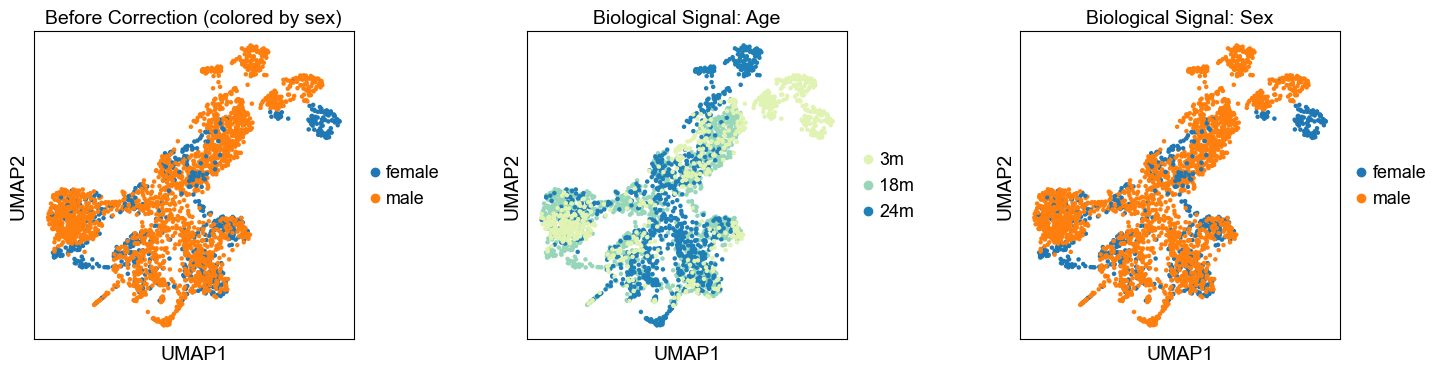

2026-04-13 11:03:10,007 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
Computing initial centroids with sklearn.KMeans...



--- Running Harmony for batch correction ---


2026-04-13 11:03:11,169 - harmonypy - INFO - sklearn.KMeans initialization complete.
sklearn.KMeans initialization complete.
2026-04-13 11:03:11,199 - harmonypy - INFO - Iteration 1 of 10
Iteration 1 of 10
2026-04-13 11:03:11,896 - harmonypy - INFO - Iteration 2 of 10
Iteration 2 of 10
2026-04-13 11:03:12,566 - harmonypy - INFO - Iteration 3 of 10
Iteration 3 of 10
2026-04-13 11:03:13,155 - harmonypy - INFO - Iteration 4 of 10
Iteration 4 of 10
2026-04-13 11:03:13,676 - harmonypy - INFO - Iteration 5 of 10
Iteration 5 of 10
2026-04-13 11:03:14,160 - harmonypy - INFO - Converged after 5 iterations
Converged after 5 iterations


Harmony correction complete. Corrected embedding stored in '.obsm['X_pca_harmony']'.

--- Running downstream analysis on corrected data ---

--- Visualizing data AFTER batch correction ---


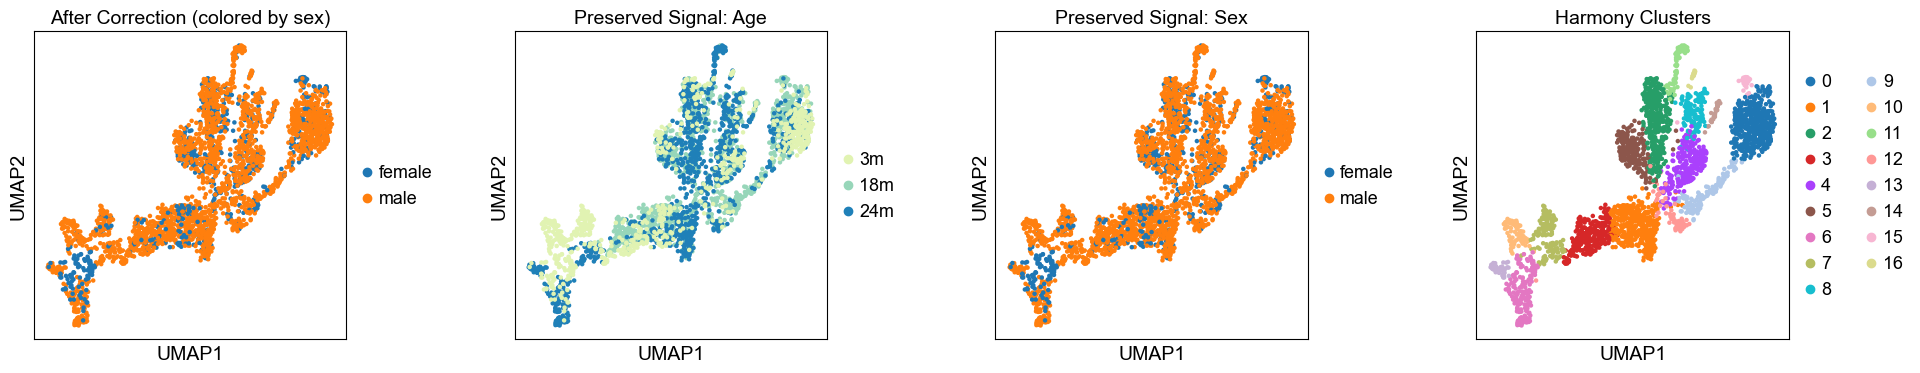


Process complete. Your batch-corrected data is ready for further analysis.


In [ ]:
# --- Step 1: Define Input and Output Filenames ---
input_filename = "Liver_facs_filtered_nonzero_normalized_HVG_reduced.h5ad" 
output_filename = "Liver_facs_filtered_nonzero_normalized_HVG_reduced_corrected.h5ad" 

# --- Step 2: Load Your Data ---
print(f"--- Loading data from: {input_filename} ---")
adata = sc.read_h5ad(input_filename)

# --- Step 3: Define the Batch Key ---
# 'mouse.id' is the ideal key as it uniquely identifies each animal/replicate.
batch_key = 'sex'
adata.obs[batch_key] = adata.obs[batch_key].astype('category')

print(f"Using '{batch_key}' as the batch key for correction.")
print("Cell counts per batch:")
print(adata.obs[batch_key].value_counts())

# --- Step 4: Re-run Pre-processing with Batch Awareness (Best Practice) ---
# Even though PCA exists, re-calculating it based on batch-aware HVGs is more robust.
print("\n--- Re-running pre-processing for robust batch correction ---")

# Re-identify HVGs to find genes that are variable across all batches, not just one.
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key=batch_key)

# It's good practice to subset the object to only the HVGs for the PCA calculation
# This reduces noise and computational time.
adata_hvg = adata[:, adata.var.highly_variable].copy()

# Scale the data (necessary before PCA).
sc.pp.scale(adata_hvg, max_value=10)

# Re-run PCA on the scaled HVGs.
sc.tl.pca(adata_hvg, svd_solver='arpack')

# Copy the new, robust PCA back to the main object.
adata.obsm['X_pca'] = adata_hvg.obsm['X_pca']
print("Re-computation of HVGs and PCA is complete.")

# --- Step 5: Visualize Data BEFORE Correction (Diagnostic Step) ---
print("\n--- Visualizing data BEFORE batch correction ---")
# Build a temporary UMAP to visualize the uncorrected state.
sc.pp.neighbors(adata, n_pcs=20)
sc.tl.umap(adata)
sc.pl.umap(
    adata,
    color=[batch_key, 'age', 'sex'],
    title=[f'Before Correction (colored by {batch_key})', 'Biological Signal: Age', 'Biological Signal: Sex'],
    wspace=0.4,
    show=True # Set to False if running in a script
)

# --- Step 6: Run Harmony to Correct for Batch Effects ---
print("\n--- Running Harmony for batch correction ---")
harmony_corrected_pca = hm.run_harmony(
    adata.obsm['X_pca'],
    adata.obs,
    vars_use=[batch_key]
)
adata.obsm['X_pca_harmony'] = harmony_corrected_pca.Z_corr.T
print("Harmony correction complete. Corrected embedding stored in '.obsm['X_pca_harmony']'.")

# --- Step 7: Post-Correction Analysis (Using the Corrected Data) ---
print("\n--- Running downstream analysis on corrected data ---")

# Re-compute the neighborhood graph using the NEW Harmony-corrected embedding.
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_pcs=20)

# Re-compute the UMAP. This will now reflect the integrated data structure.
sc.tl.umap(adata)

# Run clustering on the corrected graph.
sc.tl.leiden(adata, resolution=1.0, key_added='leiden_harmony')

# --- Step 8: Visualize Data AFTER Correction (Verification Step) ---
print("\n--- Visualizing data AFTER batch correction ---")
sc.pl.umap(
    adata,
    color=[batch_key, 'age', 'sex', 'leiden_harmony'],
    title=[f'After Correction (colored by {batch_key})', 'Preserved Signal: Age', 'Preserved Signal: Sex', 'Harmony Clusters'],
    wspace=0.4,
    show=True # Set to False if running in a script
)

# --- Step 9: Save the Corrected Data to a New File ---
#print(f"\n--- Saving corrected AnnData object to: {output_filename} ---")
# The .write_h5ad method saves the entire object, including the new harmony
# embedding, the corrected UMAP, and the new cluster labels.
#adata.write_h5ad(output_filename)

print("\nProcess complete. Your batch-corrected data is ready for further analysis.")

Unlike regress_out which removes linear effects directly from the expression matrix, Harmony works by adjusting the positions of cells in the low-dimensional PCA space. It iteratively moves cells from different batches closer together, creating an integrated embedding. This is often better at handling complex, non-linear batch effects.

The goal is that the biological signal of interest (age) is preserved, while the batch variable (sex) is mixed.

Clustering

First I will do the clustering based on the Leiden graph clustering method recommended by ScanPy, which creates a UMAP, on the dataset (without any batch correction). The UMAP is just another way to further reduce the dimensionality of the data, using the PCA analysis, to create a neighbouring graph we correlates points based on how similar and dissimilar they are, creating clusters of similar points based on the PCA information.

Loading data with pre-computed PCA from Liver_facs_filtered_nonzero_normalized_HVG_reduced.h5ad...
Building neighborhood graph...
Running Leiden clustering for multiple resolutions...

Clustering results for multiple resolutions have been stored:
                                      leiden_0.5 leiden_0.75 leiden_1.0
index                                                                  
A10_B000767_B009945_S10.mm10-plus-4-0          0           0          0
A10_D045313_B009942_S10.mm10-plus-4-0          1           1          1
A11_B000767_B009945_S11.mm10-plus-4-0          2           2          2
A11_B001247_B009941_S11.mm10-plus-4-0          3           3          3
A11_B002688_B009944_S11.mm10-plus-4-0          4           4          4
Computing and plotting UMAP...

Plotting UMAPs for comparison...


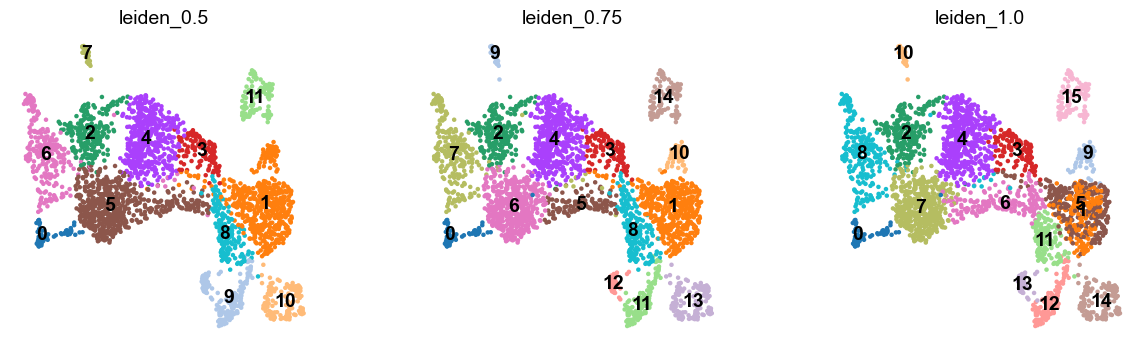

Saving clustered data to Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered.h5ad...

 Clustering script finished successfully.


In [ ]:
# Define the input file (your data with PCA already computed)
# and the name for the output file.
input_file = "Liver_facs_filtered_nonzero_normalized_HVG_reduced.h5ad"
output_file = "Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered.h5ad"

# --- 2. LOAD THE PRE-COMPUTED PCA DATA ---
print(f"Loading data with pre-computed PCA from {input_file}...")
adata = sc.read_h5ad(input_file)

# --- 3. BUILD NEIGHBORHOOD GRAPH ---
# This step uses the PCA results already stored in adata.obsm['X_pca'].
# We are creating the neighborhood graph based on the data.
print("Building neighborhood graph...")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)

# --- 4. LEIDEN CLUSTERING ON DATA ---
print("Running Leiden clustering for multiple resolutions...")

# --- Resolution 0.5 ---
sc.tl.leiden(
    adata,
    resolution=0.5,
    key_added='leiden_0.5',  # Store result in 'leiden_0.5'
    flavor="igraph",
    n_iterations=2
)

# --- Resolution 0.75 ---
sc.tl.leiden(
    adata,
    resolution=0.75,
    key_added='leiden_0.75', # Store result in 'leiden_0.75'
    flavor="igraph",
    n_iterations=2
)

# --- Resolution 1.0 ---
sc.tl.leiden(
    adata,
    resolution=1.0,
    key_added='leiden_1.0',  # Store result in 'leiden_1.0'
    flavor="igraph",
    n_iterations=2
)

# --- Verification ---
# You can now see all three results stored as separate columns in adata.obs
print("\nClustering results for multiple resolutions have been stored:")
print(adata.obs[['leiden_0.5', 'leiden_0.75', 'leiden_1.0']].head())

# --- 5. VISUALIZATION ---
# Compute the UMAP based on the graph.
print("Computing and plotting UMAP...")
sc.tl.umap(adata)

# Plot the UMAP colored by the resulting clusters and by batch.
# You should see a strong correlation between the two.
print("\nPlotting UMAPs for comparison...")
sc.pl.umap(
    adata,
    color=['leiden_0.5', 'leiden_0.75', 'leiden_1.0'], # Pass the list of your results here
    legend_loc='on data', # Puts the cluster number directly on the plot
    frameon=False,
    ncols=3 # Arrange the plots in a row with 3 columns
)
# --- 6. SAVE THE CLUSTERED DATA ---
print(f"Saving clustered data to {output_file}...")
adata.write(output_file)

print("\n Clustering script finished successfully.")

Here we can see a clustering of very closely connected points, possibly indicating a batch effect, since the borders of the clusters are somewhat poorly defined. Evaluating the clusters based on their Leiden resolution, which adds granularity and possible new clusters as it increases, we can see an increase of two new clusters from 0.5 to 0.75 resolution and then another cluster is added from 0.75 to 1.00. 

Based solely on this evaluation between these plots, I think the Leiden resolution at 1.0 may indicate a better representation of the data than the previous two. This is because the clusters it adds seem to be different populations that are closely connected to other populations. These could be the cell types described above, like immune cells, that more often than not express similar genes and in more simple analysis may be identified as a single cell type/family.

Cell Annotation

Here the goal is to assign a preliminary identity to your clusters based on existing biological knowledge. It answers the question: "Do my clusters correspond to the cell types I expect to find?".

In the manual annotation of the clusters to the cell types based on this marker set, I only assigned cell types to the clusters that presented above 50% fraction of cells in that group that had a high mean expression of a gene that corresponded with that cell type. I did not assign below 50% because I did not find that this expression was relevant enough in that small fraction of cells.

Generating dotplot for clusters in 'leiden_0.75'...


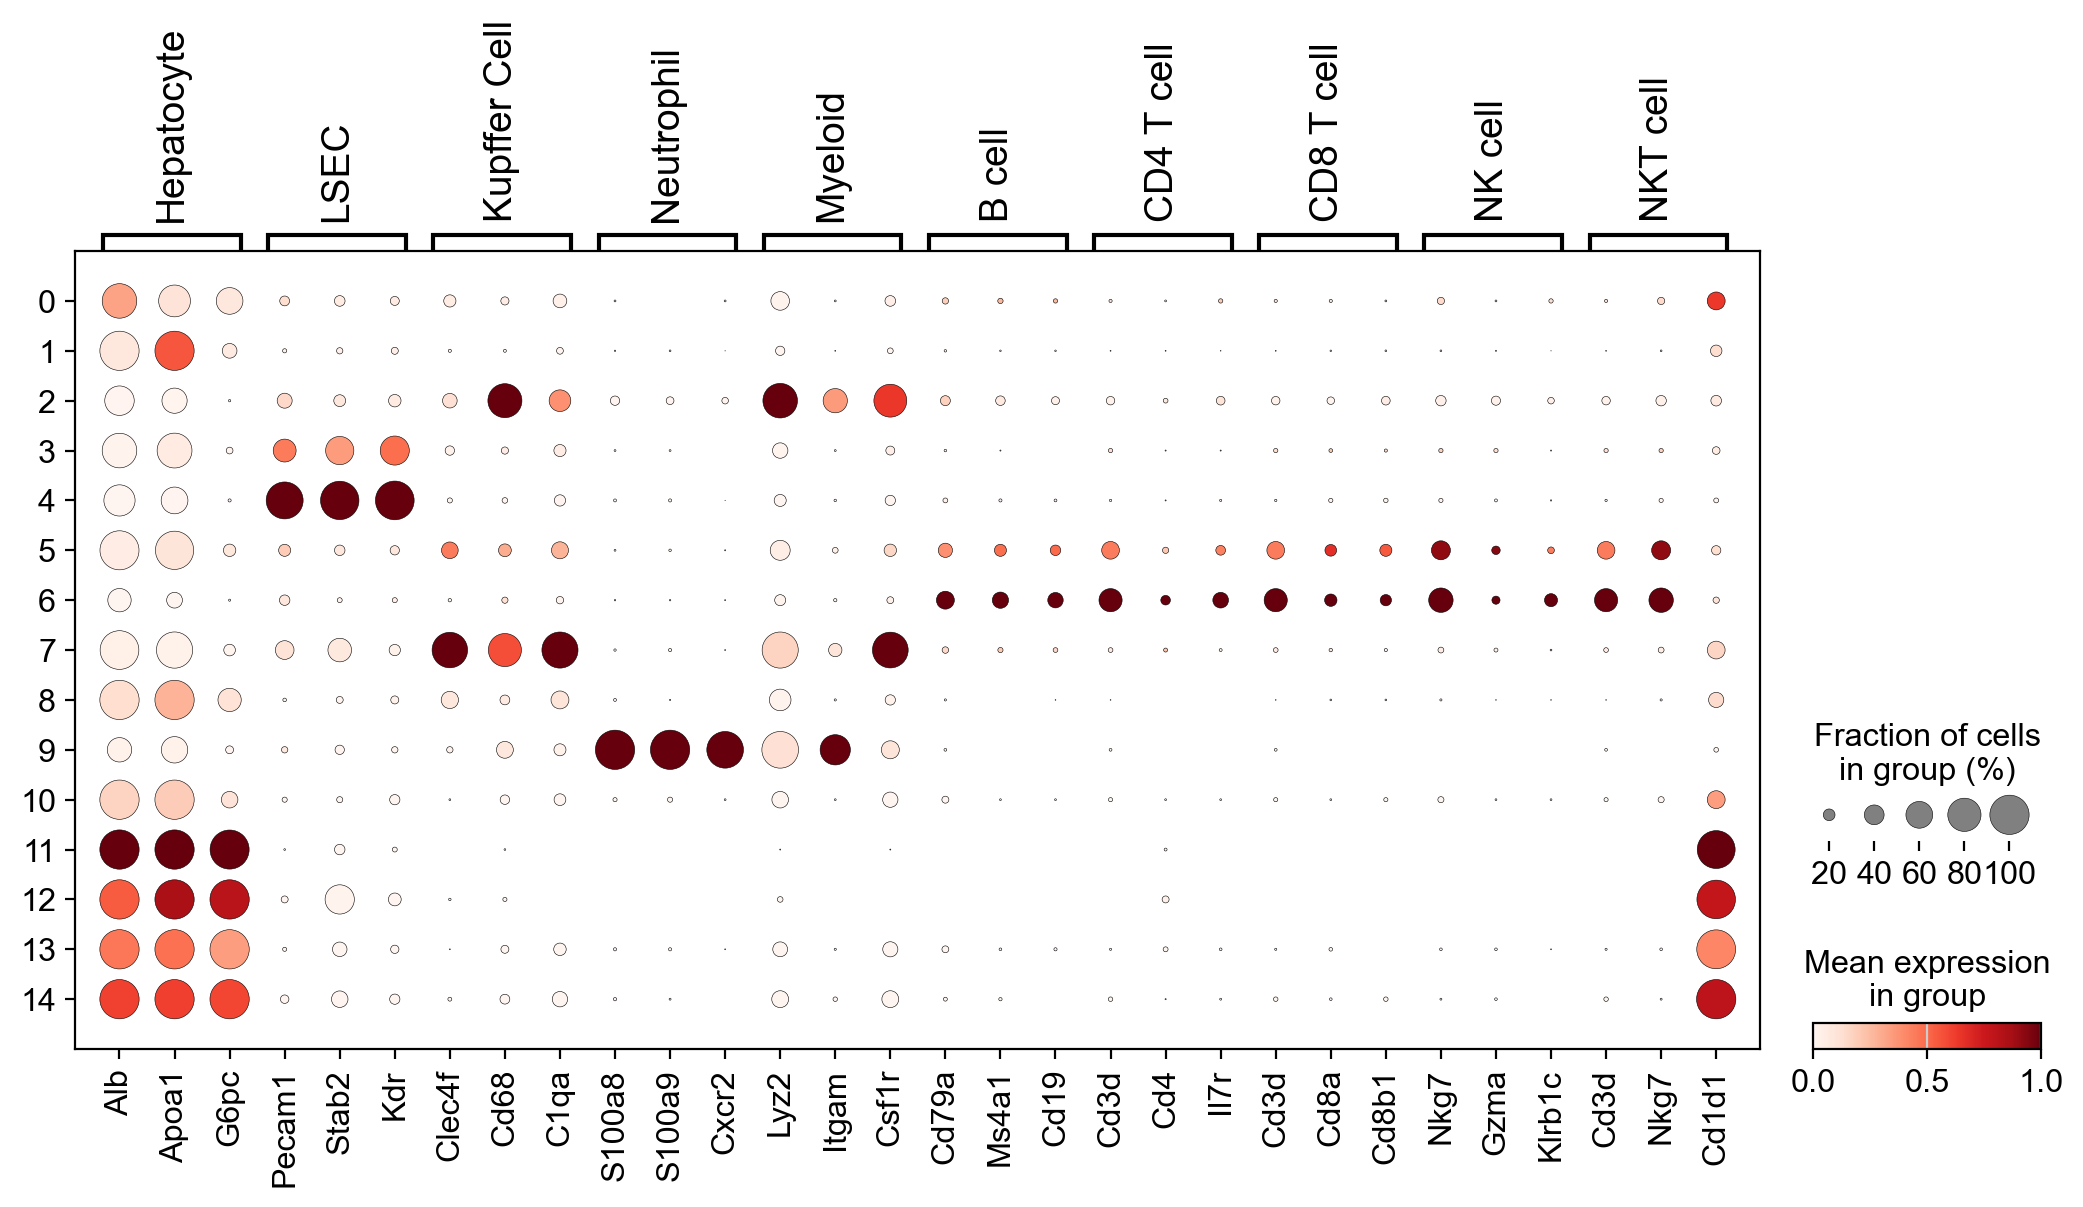


Finished mapping cluster numbers to cell type names.
Value counts for the new 'cell_type' annotation:
cell_type
Hepatocyte             745
Immune_mix             606
LSEC                   584
Kupffer/Myeloid_mix    470
Hepatocyte/NKT_mix     419
Neutrophil              34
Name: count, dtype: int64

Visualizing final annotation on UMAP...


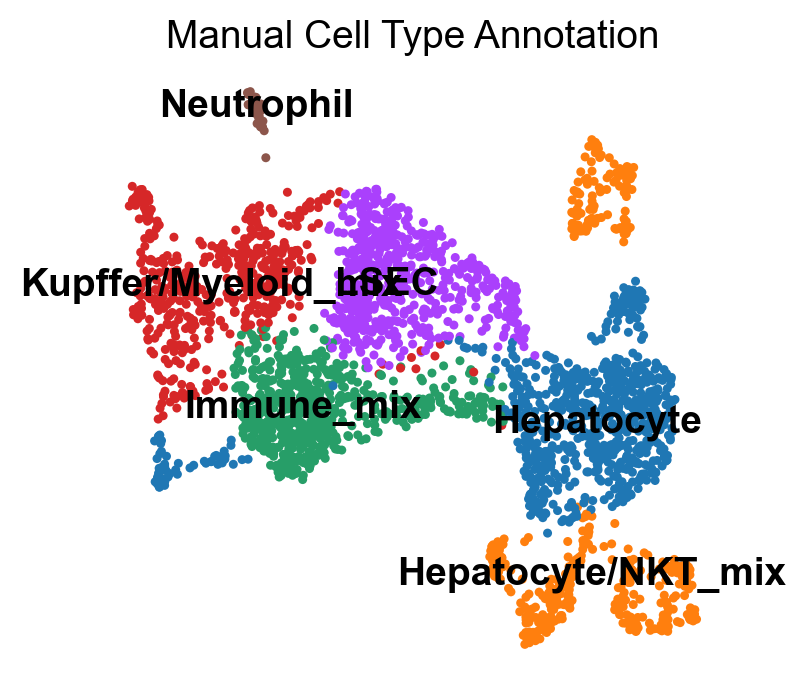


Visualizing final dotplot with cell type labels...


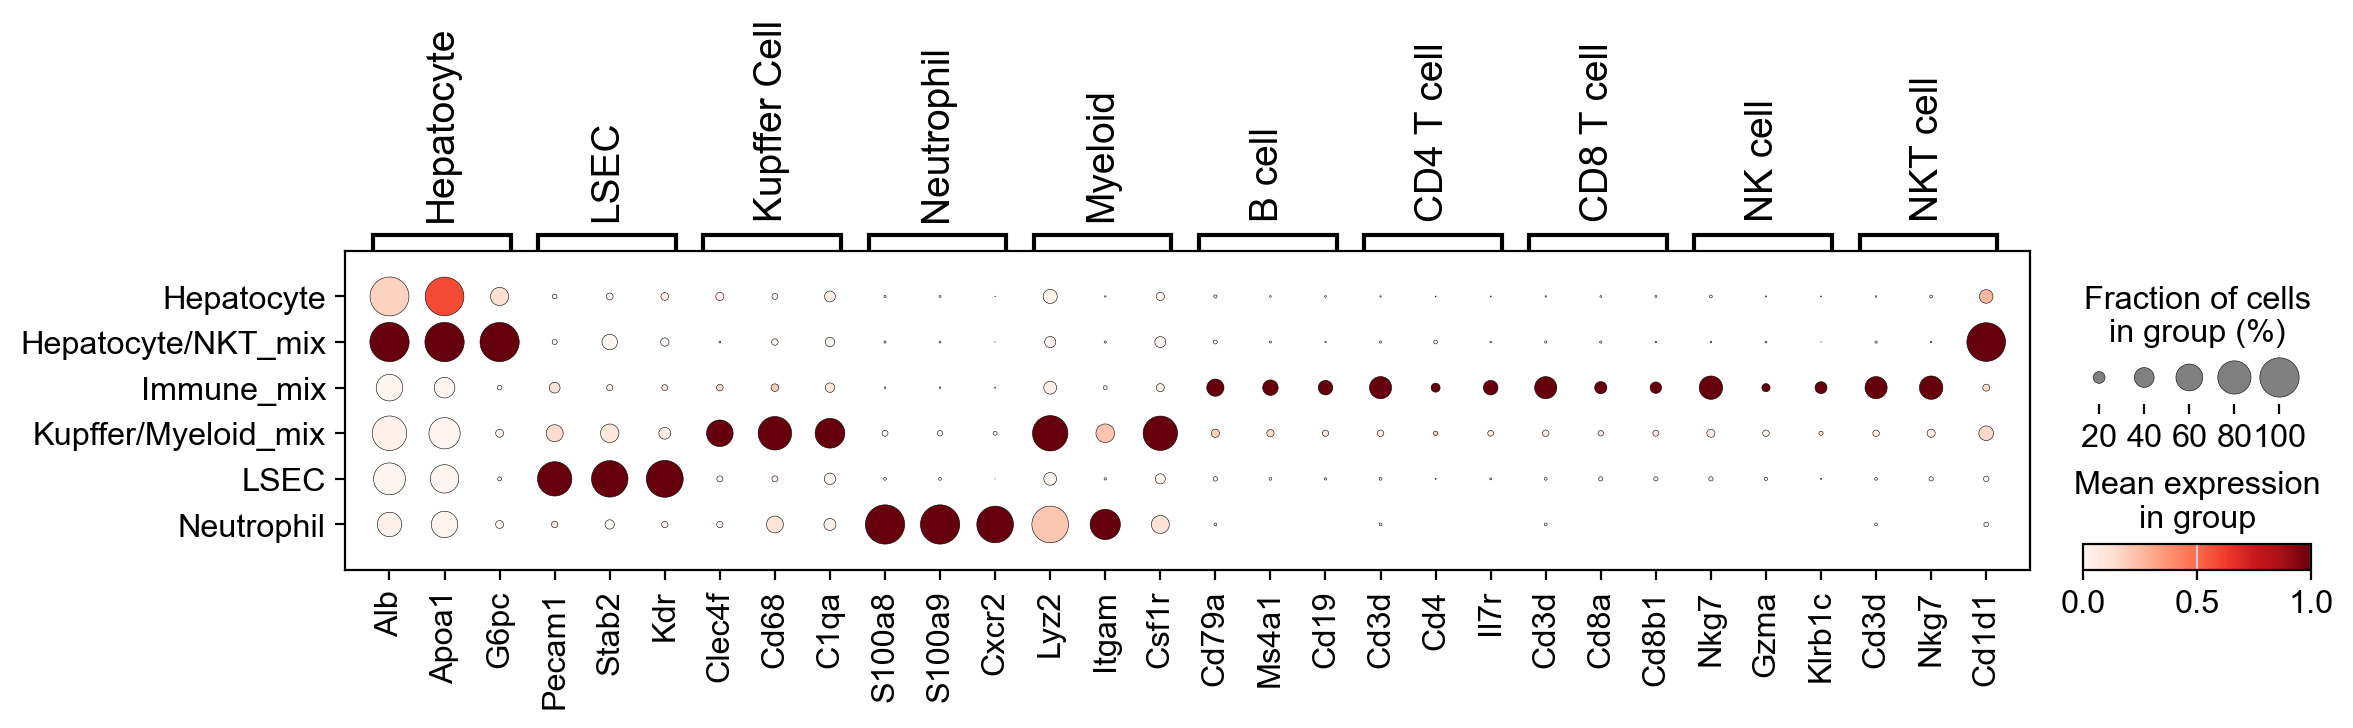

In [ ]:
# --- Manual Annotation using Marker Genes for Liver Data ---
# Setup Scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False) # Increased DPI for clarity

# 1. Load the AnnData object with clustering results
# Make sure this is the correct file containing your Leiden clustering column
adata_original = sc.read_h5ad('Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered.h5ad')

adata = adata_original.copy()

# 2. Define the new, more detailed set of marker genes for LIVER cell types
# These markers are based on the cell types you provided.
new_liver_marker_genes = {
    'Hepatocyte': ['Alb', 'Apoa1', 'G6pc'],
    'LSEC': ['Pecam1', 'Stab2', 'Kdr'], # Liver Sinusoidal Endothelial Cells
    'Kupffer Cell': ['Clec4f', 'Cd68', 'C1qa'], # Liver-resident macrophages
    'Neutrophil': ['S100a8', 'S100a9', 'Cxcr2'],
    'Myeloid': ['Lyz2', 'Itgam', "Csf1r"], # General myeloid marker (includes many types)
    'B cell': ['Cd79a', 'Ms4a1',"Cd19"], # Ms4a1 is CD20
    'CD4 T cell': ['Cd3d', 'Cd4', 'Il7r'],
    'CD8 T cell': ['Cd3d', 'Cd8a', 'Cd8b1'],
    'NK cell': ['Nkg7', 'Gzma', 'Klrb1c'], # Natural Killer cells (CD3 negative)
    'NKT cell': ['Cd3d', 'Nkg7',"Cd1d1"], # NK T cells (express both CD3 and NK markers)
}


# 3. Choose a resolution and visualize marker expression with a dotplot
# Make sure this key matches a column in your adata.obs
cluster_key_to_annotate = "leiden_0.75" # Example: using resolution 0.75

print(f"Generating dotplot for clusters in '{cluster_key_to_annotate}'...")
sc.pl.dotplot(adata, new_liver_marker_genes, groupby=cluster_key_to_annotate, standard_scale="var", show=True)

# 4. Manually map cluster numbers to cell type names based on the NEW dotplot

annotation_map = {
    '0': 'Hepatocyte',
    '1': 'Hepatocyte', 
    '2': 'Kupffer/Myeloid_mix',
    '3': 'LSEC',
    '4': 'LSEC', 
    '5': 'Immune_mix',
    '6': 'Immune_mix',
    '7': 'Kupffer/Myeloid_mix',
    '8': 'Hepatocyte',
    '9': 'Neutrophil',
    '10': 'Hepatocyte',
    '11': 'Hepatocyte/NKT_mix',
    '12': 'Hepatocyte/NKT_mix',
    '13': 'Hepatocyte/NKT_mix',
    '14': 'Hepatocyte/NKT_mix',
}

# Apply the mapping to create a new annotation column in adata.obs
if annotation_map: # Only run if the map is not empty
    adata.obs['cell_type'] = adata.obs[cluster_key_to_annotate].map(annotation_map).astype('category')
#
print("\nFinished mapping cluster numbers to cell type names.")
print("Value counts for the new 'cell_type' annotation:")
print(adata.obs['cell_type'].value_counts())
#
#     # 5. Visualize the final annotation on the UMAP
print("\nVisualizing final annotation on UMAP...")
sc.pl.umap(adata, color='cell_type', legend_loc='on data', title='Manual Cell Type Annotation', show=True)
#
#
#     # 6. Visualize the annotated dotplot for confirmation
print("\nVisualizing final dotplot with cell type labels...")
sc.pl.dotplot(adata, new_liver_marker_genes, groupby='cell_type', standard_scale='var', show=True)
#
#     # Optional: Save the final annotated object
adata.write_h5ad('Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated.h5ad')

The second image is the result of the manual annotation. Perhaps the choice of higher resolution segregated the data too much, and as a consequence the annotation identified many clusters that are representative of the same cell types. But perhaps not, since the lowest recommended resolution of 0.5 had 12 clusters, and in the end the data has but 7 clusters. Is this the marker of batch effects? Is the marker gene set poorly characterized? Is there some biological signal I'm missing?

For the biological signal we can check if there are clusters dominated by single individuals, by coloring the graphs witht he added column of age_sex.

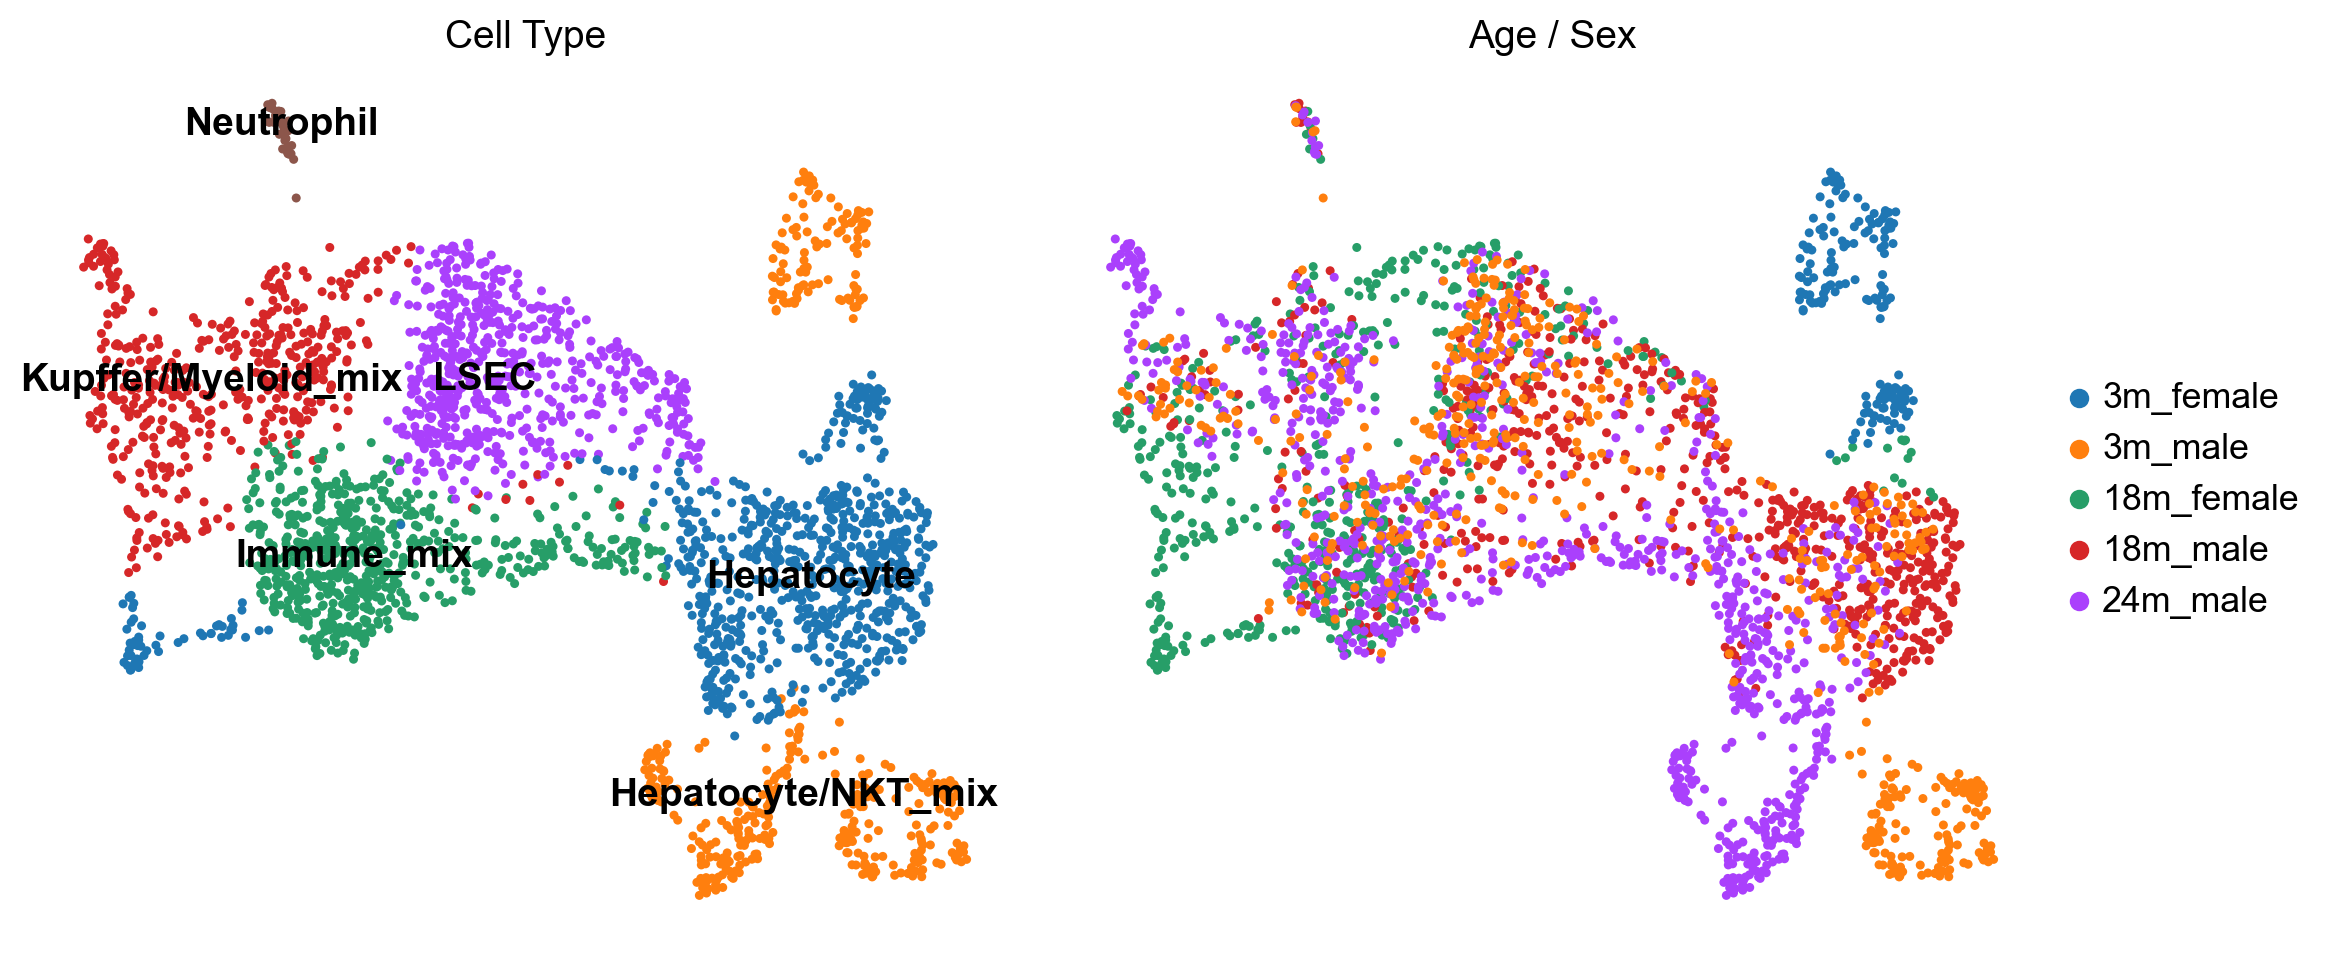

In [ ]:
# 1. Create a figure with 1 row and 2 columns of subplots
# figsize controls the overall size of the figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2. Plot 'cell_type' on the first subplot (axes[0])
# legend_loc='on data' places the legend labels directly on the clusters
sc.pl.umap(
    adata,
    color='cell_type',
    ax=axes[0],               # Specify the first subplot
    show=False,               # Do not show the plot immediately
    legend_loc='on data',     # Put the legend on the plot itself
    title='Cell Type'         # Add a title for clarity
)

# 3. Plot 'age_sex' on the second subplot (axes[1])
# legend_loc='right margin' is the default and places the legend outside
sc.pl.umap(
    adata,
    color='age_sex',
    ax=axes[1],               # Specify the second subplot
    show=False,               # Do not show the plot immediately
    legend_loc='right margin',# Put the legend in the right margin
    title='Age / Sex'         # Add a title for clarity
)

# 4. Adjust spacing and display the final figure
plt.tight_layout()
plt.show()

Clearly there are some clusters dominated by a single individual, like cluster 14 and 15. And others where one individual is most represented, like 5 or 6. Further investigation is required.

This information is a better indication of batch effects at work since, even though the annotation might be mediocre in its specificty it points to a lack of cell type heterogeneity in certain individuals that should not be the case if the sampling was done from the whole of the same tissue (liver).

Differentially expressed genes (DEG) 

Here the goal is to validate your annotations and discover the most defining features of each cluster in your specific dataset. It answers the question: "What does the data itself say is most special about these groups of cells?".

First of all the ScanPy tutorial suggests using Pseudobulking: It means you computationally "pool" the data. You take all the raw counts from the cells of a single type within one sample and add them together. This is better for a comparison of cell types between different groups, like sex and age. This is my case but I will save it for after the conventional approach.

normalizing counts per cell
    finished (0:00:00)
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
Displaying top marker genes for each annotated cell type:


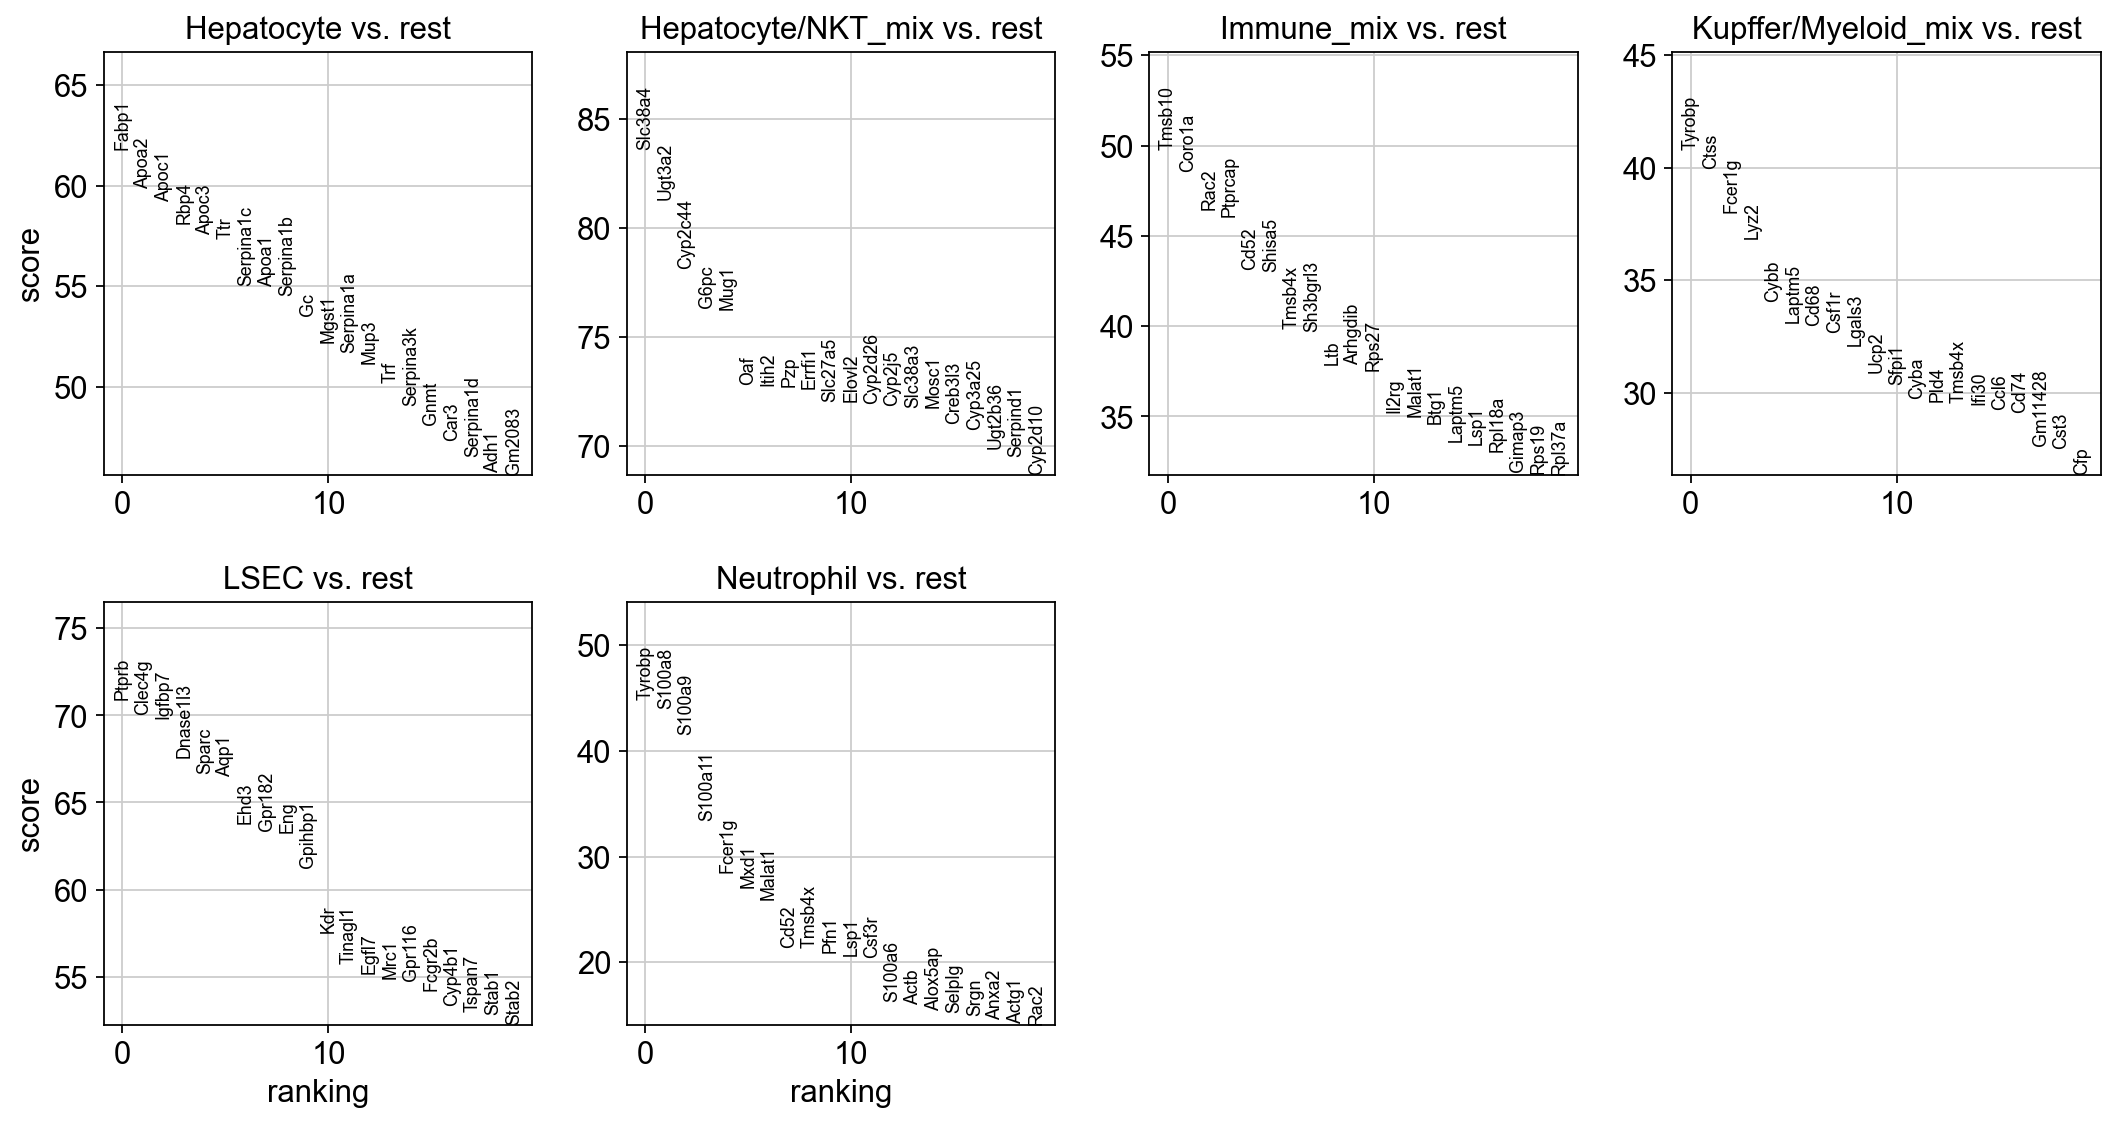

In [ ]:
# --- Differentially-Expressed Genes as Markers ---
# This script uses the data-driven `rank_genes_groups` function to find the
# top genes that define each of our manually annotated cell types.

# Setup Scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white', frameon=False)

# 1. Load the AnnData object with your manual cell_type annotations
adata = sc.read_h5ad('Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated.h5ad')

# 2. Create a new AnnData object that will hold the log-normalized data.
#    We initialize it with the raw counts from the 'counts' layer.
adata_log = sc.AnnData(adata.layers['counts'].copy())

# 3. CRUCIAL FIX: Copy the gene and cell names from the original object.
adata_log.var_names = adata.var_names
adata_log.obs_names = adata.obs_names

# 3. Perform normalization and log-transformation on this new object.
sc.pp.normalize_total(adata_log, target_sum=1e4)
sc.pp.log1p(adata_log)

# 4. Now, assign this correctly processed object to the .raw attribute of your main adata.
#    This aligns your object with the standard Scanpy workflow.
adata.raw = adata_log

# 2. Calculate differentially expressed genes for each annotated cell type
# This function will compare each cell type against all other cells to find
# genes that are uniquely upregulated. We use the 't-test' method here for speed.
sc.tl.rank_genes_groups(adata, groupby='cell_type', method='t-test', use_raw=True)

# 3. Visualize the top marker genes for each cell type
# This plot shows a bar chart of the top genes ranked by their score (e.g., t-statistic).
print("Displaying top marker genes for each annotated cell type:")
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False, show=True)

# --- How to Use This Output for Validation ---
#
# 1. Look at the bar chart for the 'Hepatocyte' group. Are the top genes
#    'Alb', 'Apoa1', 'G6pc', etc.? If YES, your annotation is strongly supported.
#
# 2. Look at the 'Kupffer Cell' group. Are the top genes 'Clec4f', 'Cd68', etc.?
#    If YES, your annotation is supported.

The top differentially expressed genes from each cluster are:

- Hepatocyte: Apoa2, Fabp1, Apoc1:

Apoa2: Strongly expressed in hepatocytes, as it is primarily synthesized in the liver and involved in plasma lipid metabolism.​

Fabp1: While classically known as a hepatocyte marker involved in fatty acid metabolism, recent evidence shows additional expression and activity in macrophages (tumor-associated macrophages, TAMs) in liver cancer contexts. However, it remains a robust hepatocyte marker and is also associated with hepatocytes in single-cell studies.​

Apoc1: Highly expressed in hepatocytes and often included in hepatocyte marker gene lists.

- Hepatocyte/NKT_mix: Slc38a4, Ugt3a2, Cyp2c44

Slc38a4, Ugt3a2, Cyp2c44: All three genes are enriched in hepatocytes, but there is evidence from NKT cell literature that some metabolic enzymes and transporters can also be expressed in NKT-enriched fractions in the liver, especially under inflammatory conditions. Their primary association remains hepatocytic, with potential upregulation in liver-resident NKT populations.

- Immune_mix: Coro1a, Tmsb10, Rac2

Coro1a, Tmsb10, Rac2: These genes are broadly associated with immune cells, especially lymphocytes and myeloid lineages. Coro1a is a cytoskeletal regulator important for leukocyte function, while Rac2 is prevalent in myeloid and lymphoid cells. Tmsb10 is a thymosin found in multiple immune cell populations.

- Kupffer/Myeloid_mix: Tyrobp, Ctss, Fcer1g

Tyrobp, Fcer1g: Universally accepted as strong markers for myeloid cells, especially murine and human macrophages (including Kupffer cells), granulocytes, and microglia. Ctss (cathepsin S) is a marker of antigen-presenting cells such as macrophages and dendritic cells, and is expressed by Kupffer cells.​

Kupffer cells: Typically co-express these myeloid genes, supporting their assignment to the Kupffer/myeloid compartment.

- LSEC: Ptprb, Clec4g, Igfbp7

Ptprb, Clec4g, Igfbp7: These are classical LSEC markers, strongly expressed in liver sinusoidal endothelial clusters based on mouse reporter studies and single-cell transcriptomics.

- Neutrophil: Tyrobp, S100a8, S100a9

S100a8 and S100a9: These genes are highly specific to neutrophils in most physiological and pathological contexts, as shown by single-cell RNA sequencing studies. While low-level expression can be detected in other myeloid cells (such as monocytes and macrophages) under inflammatory conditions, their highest and most consistent expression is in neutrophils, especially mature neutrophil clusters. S100a8/a9 are considered canonical neutrophil markers in single-cell analyses.​

Tyrobp: Tyrobp is expressed in multiple myeloid lineages, including neutrophils, macrophages, dendritic cells, and NK cells. However, in neutrophil-specific contexts, Tyrobp is present but not exclusive to neutrophils. Its expression is shared across myeloid and NK populations, so it is not a neutrophil-specific marker.

Another way to annotate and try to discern the immune cells is using a machine learning tool like celltypist:


--- Preparing data for Celltypist annotation (Normalization) ---
normalizing counts per cell
    finished (0:00:00)


🔬 Input data has 2858 cells and 19559 genes
🔗 Matching reference genes in the model



--- Running Celltypist annotation ---


🧬 7231 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!



--- Adding labels back to the main AnnData object ---
✅ Verification successful: All cells have been assigned a label.

--- Visualizing Celltypist annotations on the FACS UMAP ---

--- Visualizing Manual annotations ---

Successfully saved final annotated data to 'Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated.h5ad'


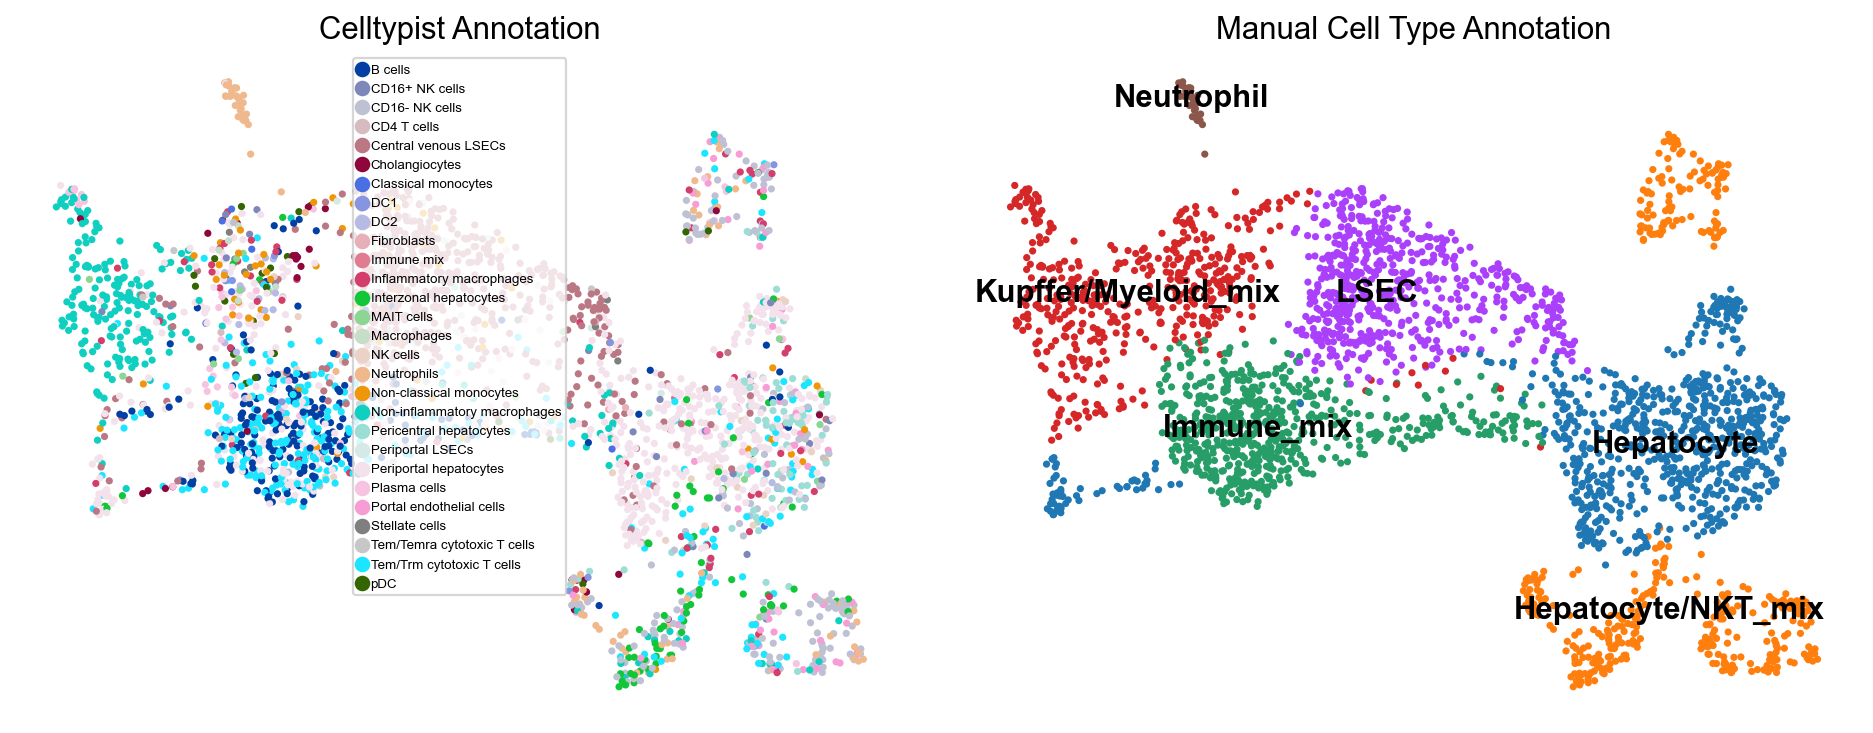

In [ ]:
# --- Step 1: Load your Harmony-corrected data ---
adata_original = sc.read_h5ad('Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated.h5ad')
model = celltypist.models.Model.load(model = 'Adult_Human_Liver.pkl')

# --- Step 3: Standardize Gene Names (Same as before) ---
adata.var['mouse_gene_symbols'] = adata.var.index
adata.var.index = adata.var.index.str.upper()
adata.var_names = adata.var.index.str.upper()
adata.var_names_make_unique()

# --- Step 4: Prepare data for Celltypist (Normalization) ---
print("\n--- Preparing data for Celltypist annotation (Normalization) ---")
if 'counts' not in adata.layers:
    raise KeyError("Error: 'counts' layer not found.")

# ====================================================================================
# --- THE CRUCIAL FIX IS HERE ---
# Create the temporary AnnData object, but this time, we pass the original `obs`
# and `var` DataFrames to ensure the cell and gene indices are perfectly preserved.
adata_for_celltypist = sc.AnnData(X=adata.layers['counts'].copy(),
                                  obs=adata.obs.copy(),   # <-- This preserves the cell barcodes/index
                                  var=adata.var.copy())   # <-- This preserves the gene names/index
# ====================================================================================

# Normalize and log-transform the temporary object
sc.pp.normalize_total(adata_for_celltypist, target_sum=1e4)
sc.pp.log1p(adata_for_celltypist)

# --- Step 5: Run Annotation ---
print("\n--- Running Celltypist annotation ---")
predictions = celltypist.annotate(adata_for_celltypist, model = model)

# --- Step 6: Add Labels to Your Main Object ---
print("\n--- Adding labels back to the main AnnData object ---")
# This assignment will now work because both DataFrames share the same cell barcode index.
adata.obs['celltypist_predicted_labels'] = predictions.predicted_labels['predicted_labels']

# --- ADD A VERIFICATION STEP ---
# Let's check if the assignment was successful by seeing how many values are NaN.
nan_count = adata.obs['celltypist_predicted_labels'].isna().sum()
if nan_count > 0:
    print(f"⚠️ Warning: Found {nan_count} cells that were not annotated (NaN values).")
else:
    print("✅ Verification successful: All cells have been assigned a label.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Step 7: Visualize ---
print("\n--- Visualizing Celltypist annotations on the FACS UMAP ---")
sc.pl.umap(
    adata,
    color='celltypist_predicted_labels',
    ax=axes[0],
    show=False,
    legend_loc='upper center', # <-- KEY CHANGE: Use 'on data' for a clean, internal legend
    legend_fontsize=6,   # Adjust font size as needed for clarity
    title='Celltypist Annotation'
)

# --- Plot 2: Manual Annotation ---
# For this plot, 'right margin' might be fine, or you can also use 'on data' for consistency.
print("\n--- Visualizing Manual annotations ---")
sc.pl.umap(
    adata,
    color='cell_type',
    ax=axes[1],
    show=False,
    legend_loc='on data', # Using 'on data' here too for a consistent look
    title='Manual Cell Type Annotation'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Optional: Save the final, celltypist-annotated object
final_output_filename = 'Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated.h5ad'
adata.write_h5ad(final_output_filename)
print(f"\nSuccessfully saved final annotated data to '{final_output_filename}'")

--- Creating confusion matrix ---
--- Plotting heatmap of raw cell counts ---


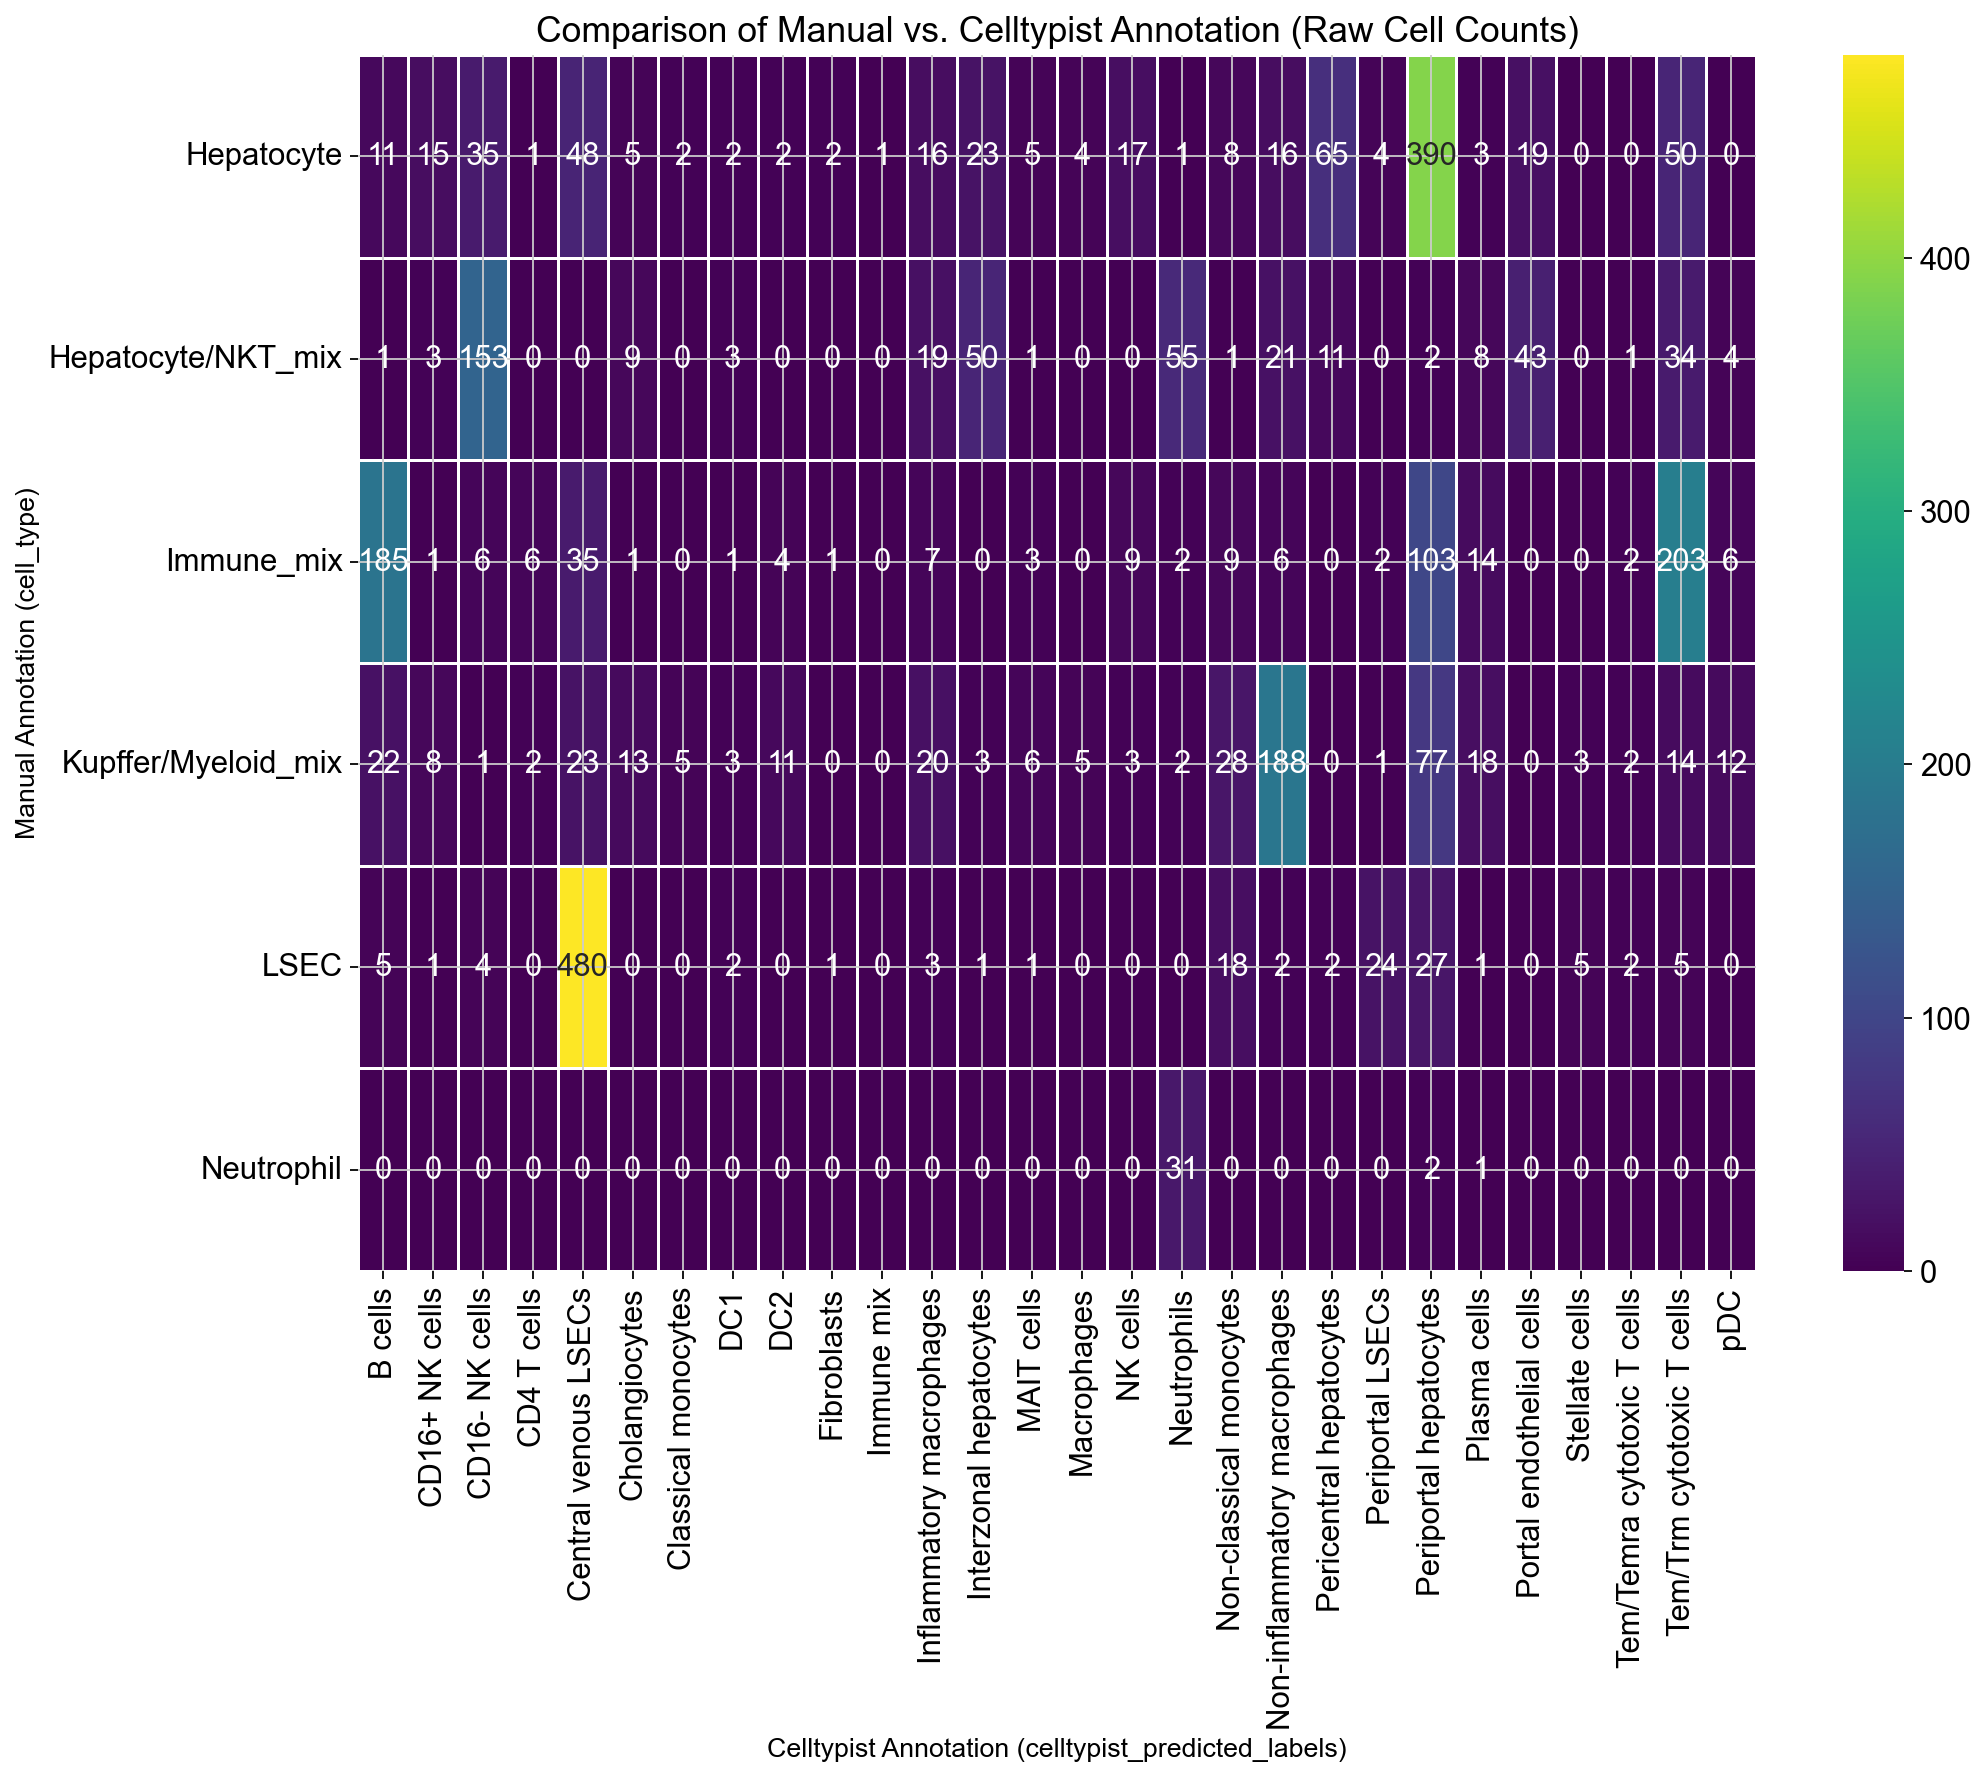

In [ ]:
# --- Step 1: Load the final annotated AnnData object ---
# This object MUST contain both your manual and celltypist annotation columns.
# Replace with the correct filename.
adata = sc.read_h5ad('Liver_facs_filtered_nonzero_normalized_HVG_reduced_clustered_annotated.h5ad')

# --- Step 2: Define the column names for comparison ---
# ### <<< ACTION REQUIRED: Make sure these column names are correct! ###
# Find the exact name of your manual annotation column in adata.obs
manual_col = 'cell_type' # e.g., 'leiden_harmony', 'cell_type', etc.
# The name of the celltypist annotation column we just created
celltypist_col = 'celltypist_predicted_labels'

# --- Verification Step ---
# Check if these columns actually exist in the data to avoid errors.
if manual_col not in adata.obs.columns:
    raise KeyError(f"Error: Manual annotation column '{manual_col}' not found in adata.obs. Please provide the correct name.")
if celltypist_col not in adata.obs.columns:
    raise KeyError(f"Error: Celltypist annotation column '{celltypist_col}' not found in adata.obs. Please provide the correct name.")

# --- Step 3: Create the Confusion Matrix (Contingency Table) ---
# We use pandas.crosstab to count the occurrences of each pair of labels.
print("--- Creating confusion matrix ---")
confusion_matrix = pd.crosstab(
    adata.obs[manual_col],      # The rows of the heatmap (your manual labels)
    adata.obs[celltypist_col]   # The columns of the heatmap (celltypist's labels)
)

# --- Step 4: Plot the Heatmap of Raw Cell Counts ---
print("--- Plotting heatmap of raw cell counts ---")
plt.figure(figsize=(14, 10))
sns.heatmap(
    confusion_matrix,
    annot=True,      # Show the actual numbers in each cell
    fmt='d',         # Format numbers as integers
    cmap='viridis',  # A color-blind friendly colormap
    linewidths=.5
)
plt.title('Comparison of Manual vs. Celltypist Annotation (Raw Cell Counts)', fontsize=16)
plt.ylabel(f'Manual Annotation ({manual_col})', fontsize=12)
plt.xlabel(f'Celltypist Annotation ({celltypist_col})', fontsize=12)
plt.show()


This heatmap correlates the manual annotation with the automatic annotation of the celltypist tool. From what we can see the manual annotation was succesful but unspecific. We could add the automatic annotation to the manual one as a complementary aid to better discern cell types. But since the use of this tool was autonomous on my part I will not deviate from the workflow tutorial and will keep this in my back pocket.